## packages

In [11]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
import warnings
from dateutil.relativedelta import relativedelta
from dateutil import parser
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

## data prep

In [13]:
# Function call to process the tradewed data file
def data_preprocess(filepath):
    rawdata = pd.read_csv(filepath)
    rawdata = rawdata.loc[rawdata['ACCEPTEDVOL'] != 0] # Ignore trade stamps with zero volume
    # Remove BILLs , STRIPs and TRSY FRN data to skip the computation from yield to price for Bills and negative spreads for Strips + Treasury FRN
    substring = 'Bill'
    substring2 = 'Strip'
    substring3 = 'TRSY FRN'
    filter = rawdata['MATURITY_RANGE'].str.contains(substring)
    rawdata = rawdata[~filter]
    filter2 = rawdata['MATURITY_RANGE'].str.contains(substring2)
    rawdata = rawdata[~filter2]
    filter3 = rawdata['MATURITY_RANGE'].str.contains(substring3)
    rawdata = rawdata[~filter3]
    rawdata = rawdata.loc[rawdata['TRADETYPE'] == 'OUTRIGHT'] # Only consider outright trades
    rawdata.reset_index(inplace=True)
    # Convert TRADETIME , MATURITY DATE and TRADE DATE to datetime and assign new index
    tradetime = []
    tradedate = []
    maturitydate = []
    for i in range(rawdata.shape[0]):
        tradetime.append(datetime.datetime.strptime(rawdata['TRADETIME'].iloc[i].rstrip(' Z'), "%Y-%m-%d %H:%M:%S.%f"))
        tradedate.append(datetime.datetime.strptime(rawdata['TRADEDATE'].iloc[i], '%m/%d/%y'))
        maturitydate.append(datetime.datetime.strptime(rawdata['MATURITY_DATE'].iloc[i], '%m/%d/%y'))
    rawdata['TIMESTAMP'] = tradetime
    rawdata['TRADEDATE'] = tradedate
    rawdata['MATURITY_DATE'] = maturitydate
    rawdata.set_index('TIMESTAMP', inplace= True)
    rawdata.sort_index(inplace=True)
    return rawdata

In [14]:
tw1 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 1.csv')
tw2 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 2.csv')
tw3 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 3.csv')
tw4 = data_preprocess('/Users/jiangzixuan/Desktop/Blockhouse/Blockhouse Data 4.csv')
rawdata = pd.concat([tw1, tw2, tw3, tw4], axis =0)

In [15]:
rawdata.columns

Index(['index', 'TRADEDATE', 'DEALER', 'DEALERCOUNT', 'ACCEPTED',
       'SEEN_INQUIRY', 'ACCEPTEDVOL', 'SEENVOLUME', 'PRICE', 'TRADETIME',
       'INSTRUMENT', 'INSTRUMENT_DESC', 'MATURITY_DATE', 'MATURITY_RANGE',
       'COUPON_RATE', 'SIDE', 'COMP_ASK', 'COMP_BID', 'PROTOCOL', 'TRADETYPE',
       'SOURCE'],
      dtype='object')

In [16]:
rawdata.head(5)

,index,TRADEDATE,DEALER,DEALERCOUNT,ACCEPTED,SEEN_INQUIRY,ACCEPTEDVOL,SEENVOLUME,PRICE,TRADETIME,...,INSTRUMENT_DESC,MATURITY_DATE,MATURITY_RANGE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,PROTOCOL,TRADETYPE,SOURCE
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,47059,2023-10-02,D69,5,1,1,1100.90,1100.90,99.761887,2023-10-02 06:47:43.000 Z,...,"T 4 5/8 <MD2Y,2462045> 5yr",2028-09-30,Note 3.5 - 5.5 Year,4.625,BUY,99.769531,99.753906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,19829,2023-10-02,D38,5,1,1,3939.00,3939.00,99.691574,2023-10-02 06:47:43.000 Z,...,"T 5 <MD2Y,2460919>",2025-08-31,Note 1.5 - 3.5 Year,5.000,BUY,99.703125,99.691406,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,50786,2023-10-02,D28,5,1,1,297.95,297.95,89.461106,2023-10-02 06:47:43.000 Z,...,"T 1 1/8 <MD2Y,2461345>",2026-10-31,Note 1.5 - 3.5 Year,1.125,BUY,89.488281,89.433594,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,24582,2023-10-02,D38,5,1,1,676.70,676.70,90.133013,2023-10-02 06:47:43.000 Z,...,"T 4 1/8 <MD2Y,2471130> 30yr",2053-08-15,Note >10 Year,4.125,BUY,90.160156,90.128906,REG List,OUTRIGHT,TW
2023-10-02 06:47:43,57986,2023-10-02,D11,5,1,1,176.75,176.75,60.906450,2023-10-02 06:47:43.000 Z,...,"T 2 1/4 <MD2Y,2470583>",2052-02-15,Note >10 Year,2.250,BUY,60.960938,60.882812,REG List,OUTRIGHT,TW


In [17]:
filtered_rawdata = rawdata[['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE','MATURITY_DATE', 'TRADEDATE',"COUPON_RATE",'SIDE','COMP_ASK','COMP_BID']].copy()
filtered_rawdata.head()

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID
TIMESTAMP,,,,,,,,,,,
2023-10-02 06:47:43,D69,1100.90,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906
2023-10-02 06:47:43,D38,3939.00,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406
2023-10-02 06:47:43,D28,297.95,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594
2023-10-02 06:47:43,D38,676.70,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906
2023-10-02 06:47:43,D11,176.75,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812


In [18]:
filtered_rawdata.shape

(50741, 11)

In [19]:
filtered_rawdata['SIGN'] = filtered_rawdata['SIDE'].apply(lambda x: 1 if x == 'BUY' else -1)
filtered_rawdata['ACCEPTEDVOL'] = filtered_rawdata['ACCEPTEDVOL'] * 10
filtered_rawdata['SIGNED_VOLUME'] = filtered_rawdata['ACCEPTEDVOL'] * filtered_rawdata['SIGN']
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME
TIMESTAMP,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0


In [20]:
# Calculate years to maturity
ytm = []
for i in range(0,rawdata.shape[0]):
    ytm.append(relativedelta(filtered_rawdata['MATURITY_DATE'].iloc[i],filtered_rawdata['TRADEDATE'].iloc[i]).years)
filtered_rawdata['Years to Maturity'] = ytm
# calculate spreads
filtered_rawdata['Spread'] = (filtered_rawdata['COMP_ASK'] - filtered_rawdata['COMP_BID'])/2

In [21]:
filtered_rawdata['MATURITY_RANGE'].unique()

array(['Note 3.5 - 5.5 Year', 'Note 1.5 - 3.5 Year', 'Note >10 Year',
       'Note 5.5 - 10 Year', 'Note 0 - 1.5 Year', 'TIPS 0 - 5 year',
       'TIPS 5 - 10 year', 'TIPS > 10 year'], dtype=object)

In [22]:
filtered_rawdata

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread
TIMESTAMP,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250


In [23]:
# Convert PRICE, COMP_BID, COMP_ASK from dollar terms to yield terms
filtered_rawdata['PRICE_YIELD'] = (filtered_rawdata['COUPON_RATE'] / filtered_rawdata['PRICE']) * 100
filtered_rawdata['COMP_BID_YIELD'] = (filtered_rawdata['COUPON_RATE'] / filtered_rawdata['COMP_BID']) * 100
filtered_rawdata['COMP_ASK_YIELD'] = (filtered_rawdata['COUPON_RATE'] / filtered_rawdata['COMP_ASK']) * 100

# Display the result
print(filtered_rawdata[['PRICE', 'COMP_BID', 'COMP_ASK', 'COUPON_RATE', 'PRICE_YIELD', 'COMP_BID_YIELD', 'COMP_ASK_YIELD']])

                         PRICE   COMP_BID   COMP_ASK  COUPON_RATE  \
TIMESTAMP                                                           
2023-10-02 06:47:43  99.761887  99.753906  99.769531        4.625   
2023-10-02 06:47:43  99.691574  99.691406  99.703125        5.000   
2023-10-02 06:47:43  89.461106  89.433594  89.488281        1.125   
2023-10-02 06:47:43  90.133013  90.128906  90.160156        4.125   
2023-10-02 06:47:43  60.906450  60.882812  60.960938        2.250   
...                        ...        ...        ...          ...   
2023-12-29 13:51:46  97.605301  97.585938  97.640625        2.125   
2023-12-29 13:51:46  95.769699  95.726562  95.820312        2.875   
2023-12-29 13:51:46  97.574051  97.542969  97.605469        2.250   
2023-12-29 13:51:46  97.042801  97.011719  97.074219        1.500   
2023-12-29 13:51:46  97.695144  97.683594  97.726562        2.500   

                     PRICE_YIELD  COMP_BID_YIELD  COMP_ASK_YIELD  
TIMESTAMP                          

In [24]:
# Define slippage calculation function in bps
def calculate_slippage(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE_YIELD'] - row['MID_yield']) / row['MID_yield'] * 10000  # Buy side slippage in bps
    elif row['SIDE'] == 'SELL':
        return (row['MID_yield'] - row['PRICE_YIELD']) / row['MID_yield'] * 10000  # Sell side slippage in bps
    return None

# Calculate MID_yield
filtered_rawdata['MID_yield'] = (filtered_rawdata['COMP_BID_YIELD'] + filtered_rawdata['COMP_ASK_YIELD']) / 2

filtered_rawdata['Slippage_bps'] = filtered_rawdata.apply(calculate_slippage, axis=1)

print(filtered_rawdata[['PRICE_YIELD', 'COMP_BID_YIELD', 'COMP_ASK_YIELD', 'MID_yield', 'Slippage_bps']])

                     PRICE_YIELD  COMP_BID_YIELD  COMP_ASK_YIELD  MID_yield  \
TIMESTAMP                                                                     
2023-10-02 06:47:43     4.636039        4.636410        4.635684   4.636047   
2023-10-02 06:47:43     5.015469        5.015477        5.014888   5.015183   
2023-10-02 06:47:43     1.257530        1.257917        1.257148   1.257532   
2023-10-02 06:47:43     4.576570        4.576778        4.575192   4.575985   
2023-10-02 06:47:43     3.694190        3.695624        3.690888   3.693256   
...                          ...             ...             ...        ...   
2023-12-29 13:51:46     2.177136        2.177568        2.176348   2.176958   
2023-12-29 13:51:46     3.001993        3.003346        3.000408   3.001877   
2023-12-29 13:51:46     2.305941        2.306676        2.305199   2.305937   
2023-12-29 13:51:46     1.545710        1.546205        1.545209   1.545707   
2023-12-29 13:51:46     2.558981        2.559283    

In [25]:
filtered_rawdata['Slippage_bps']

TIMESTAMP
2023-10-02 06:47:43   -0.016901
2023-10-02 06:47:43    0.570864
2023-10-02 06:47:43   -0.019713
2023-10-02 06:47:43    1.277672
2023-10-02 06:47:43    2.528460
                         ...   
2023-12-29 13:51:46   -0.816845
2023-12-29 13:51:46    0.387942
2023-12-29 13:51:46   -0.016192
2023-12-29 13:51:46   -0.016275
2023-12-29 13:51:46   -1.016315
Name: Slippage_bps, Length: 50741, dtype: float64

## Parameter for Price Impact Model: daily_vol, adv, beta

In [27]:
filtered_rawdata.MATURITY_RANGE.value_counts()

Note 1.5 - 3.5 Year    12244
Note 0 - 1.5 Year       9955
Note >10 Year           8946
Note 5.5 - 10 Year      8760
Note 3.5 - 5.5 Year     7661
TIPS 0 - 5 year         1620
TIPS > 10 year           782
TIPS 5 - 10 year         773
Name: MATURITY_RANGE, dtype: int64

## select one maturity data

In [29]:
# List of maturity ranges to filter
note_maturity_ranges = ['Note 1.5 - 3.5 Year', 'Note 0 - 1.5 Year', 'Note >10 Year',
                        'Note 5.5 - 10 Year', 'Note 3.5 - 5.5 Year']

# Filter data for the specified maturity ranges
group1 = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'].isin(note_maturity_ranges)]


group1

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,COMP_BID,SIGN,SIGNED_VOLUME,Years to Maturity,Spread,PRICE_YIELD,COMP_BID_YIELD,COMP_ASK_YIELD,MID_yield,Slippage_bps
TIMESTAMP,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:47:43,D69,11009.0,99.761887,91282CJA0,Note 3.5 - 5.5 Year,2028-09-30,2023-10-02,4.625,BUY,99.769531,99.753906,1,11009.0,4,0.007812,4.636039,4.636410,4.635684,4.636047,-0.016901
2023-10-02 06:47:43,D38,39390.0,99.691574,91282CHV6,Note 1.5 - 3.5 Year,2025-08-31,2023-10-02,5.000,BUY,99.703125,99.691406,1,39390.0,1,0.005859,5.015469,5.015477,5.014888,5.015183,0.570864
2023-10-02 06:47:43,D28,2979.5,89.461106,91282CDG3,Note 1.5 - 3.5 Year,2026-10-31,2023-10-02,1.125,BUY,89.488281,89.433594,1,2979.5,3,0.027344,1.257530,1.257917,1.257148,1.257532,-0.019713
2023-10-02 06:47:43,D38,6767.0,90.133013,912810TT5,Note >10 Year,2053-08-15,2023-10-02,4.125,BUY,90.160156,90.128906,1,6767.0,29,0.015625,4.576570,4.576778,4.575192,4.575985,1.277672
2023-10-02 06:47:43,D11,1767.5,60.906450,912810TD0,Note >10 Year,2052-02-15,2023-10-02,2.250,BUY,60.960938,60.882812,1,1767.5,28,0.039062,3.694190,3.695624,3.690888,3.693256,2.528460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:51:46,D50,202000.0,97.605301,9128283J7,Note 0 - 1.5 Year,2024-11-30,2023-12-29,2.125,SELL,97.640625,97.585938,-1,-202000.0,0,0.027344,2.177136,2.177568,2.176348,2.176958,-0.816845
2023-12-29 13:51:46,D50,121200.0,95.769699,9128284V9,Note 3.5 - 5.5 Year,2028-08-15,2023-12-29,2.875,BUY,95.820312,95.726562,1,121200.0,4,0.046875,3.001993,3.003346,3.000408,3.001877,0.387942
2023-12-29 13:51:46,D28,252500.0,97.574051,9128283P3,Note 0 - 1.5 Year,2024-12-31,2023-12-29,2.250,SELL,97.605469,97.542969,-1,-252500.0,1,0.031250,2.305941,2.306676,2.305199,2.305937,-0.016192


In [30]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Group by 'TRADEDATE' and calculate the daily volatility as the standard deviation of 'PRICE'
daily_volatility = group1.groupby('TRADEDATE')['PRICE'].std()

# Map the daily volatility back to the original DataFrame
group1['Daily_Volatility'] = group1['TRADEDATE'].map(daily_volatility)

## daily volatility

In [32]:
group1.Daily_Volatility

TIMESTAMP
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
2023-10-02 06:47:43    12.553247
                         ...    
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
2023-12-29 13:51:46     9.042891
Name: Daily_Volatility, Length: 47566, dtype: float64

## ADV: average daily volume

In [34]:
def calculate_monthly_adv_separately(data):
    # resample volume to daily
    daily_vol = data['ACCEPTEDVOL'].resample('D').sum()
    print("Daily Total Volume:\n", daily_vol.head(10))

    october_total_vol = daily_vol[0]  # total volume for October
    december_total_vol = daily_vol[2]  # total volume for December
    # Calculate the number of trading days for October and December
    october_trading_days = data['ACCEPTEDVOL']['2023-10'].count()
    december_trading_days = data['ACCEPTEDVOL']['2023-12'].count()

    # Calculate ADV
    october_adv = october_total_vol / october_trading_days
    december_adv = december_total_vol / december_trading_days

    # Assign the ADV value
    data.loc['2023-10', 'ADV'] = october_adv
    data.loc['2023-12', 'ADV'] = december_adv

    # Forward fill for consistency
    data['ADV'].fillna(method='ffill', inplace=True)
    data['ADV'].fillna(method='bfill', inplace=True)

    return data[['ADV']], october_total_vol, december_total_vol

In [35]:
group1[['ADV']], october_total_vol, december_total_vol = calculate_monthly_adv_separately(group1)

Daily Total Volume:
 TIMESTAMP
2023-10-02    14129669.72
2023-10-03    12331141.51
2023-10-04    10819414.92
2023-10-05     8190788.92
2023-10-06     6369606.41
2023-10-07           0.00
2023-10-08           0.00
2023-10-09           0.00
2023-10-10    13034806.49
2023-10-11    11529757.01
Freq: D, Name: ACCEPTEDVOL, dtype: float64


In [36]:
group1.ADV

TIMESTAMP
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
2023-10-02 06:47:43    602.570247
                          ...    
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
2023-12-29 13:51:46    448.621923
Name: ADV, Length: 47566, dtype: float64

In [37]:
print('OCT',october_total_vol)
print('DEC',december_total_vol)

OCT 14129669.72
DEC 10819414.92


In [38]:
import math
beta = math.log(2)/1 # half-life is 30min, bin is 60 min
print('beta:',beta)

beta: 0.6931471805599453


## qt: quanity/volume in each bin (set bin 60min here)

In [40]:
def add_resampled_volume(df):
    result_df = df.copy()
    bin = result_df.index.floor('60T')
    # Calculate qt for each 60-minute window
    qt = (result_df.groupby(bin)['SIGNED_VOLUME']
                .transform('sum'))
    result_df['qt'] = qt

    return result_df

In [41]:
group1['SIGN'].unique()

array([ 1, -1])

In [42]:
group1 = add_resampled_volume(group1)
qt = group1['SIGNED_VOLUME'].resample('60T').sum()

# Compare results
print(group1[['SIGNED_VOLUME', 'qt']])
print(qt)

                     SIGNED_VOLUME           qt
TIMESTAMP                                      
2023-10-02 06:47:43        11009.0    -24017.80
2023-10-02 06:47:43        39390.0    -24017.80
2023-10-02 06:47:43         2979.5    -24017.80
2023-10-02 06:47:43         6767.0    -24017.80
2023-10-02 06:47:43         1767.5    -24017.80
...                            ...          ...
2023-12-29 13:51:46      -202000.0  13923146.94
2023-12-29 13:51:46       121200.0  13923146.94
2023-12-29 13:51:46      -252500.0  13923146.94
2023-12-29 13:51:46      -202000.0  13923146.94
2023-12-29 13:51:46        -2020.0  13923146.94

[47566 rows x 2 columns]
TIMESTAMP
2023-10-02 06:00:00      -24017.80
2023-10-02 07:00:00      -52704.83
2023-10-02 08:00:00      141046.50
2023-10-02 09:00:00     -442632.50
2023-10-02 10:00:00      117030.72
                          ...     
2023-12-29 09:00:00      259342.75
2023-12-29 10:00:00     6066299.37
2023-12-29 11:00:00   -16554973.63
2023-12-29 12:00:00     4

In [43]:
(group1.qt == 0).value_counts()

False    47566
Name: qt, dtype: int64

In [44]:
# Function to calculate I_t and v_t using the given equations from book
def calculate_impact_and_liquidity(data, beta, delta_t, lambda_value):
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()
    data['RETURN'] = data['PRICE'].pct_change()
    data['F_t_diff'] = data['SIGNED_VOLUME'].diff()
    data.dropna(inplace=True)

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma_value = data['Daily_Volatility'].iloc[i]
        qt = data['qt'].iloc[i]
        adv_value = data['ADV'].iloc[i]
        # Calculate v_t+delta_t using the exponential moving sum of volume
        v_values[i] = v_values[i-1] + (-beta * v_values[i-1] * delta_t + abs(qt))

        # Calculate I_t+delta_t using the impact equation
        if adv_value != 0:
            I_values[i] = I_values[i-1] + (-beta * I_values[i-1] * delta_t +
                                           lambda_value * sigma_value * (qt / np.sqrt(adv_value*v_values[i])))

    # Append the calculated values to the DataFrame for further analysis
    data['I_t'] = I_values/10
    data['v_t'] = v_values

    # Include PRICE in the returned DataFrame to calculate Delta_P in the next function
    return data

### func to find lambda
Lambda is the hyperparameter of the OW model, we should select lambda with the highest R2

In [46]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

def calculate_impact_and_liquidity(data, h_minutes, delta_t=1/24):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects
        else:
            I_values[i] = I_values[i-1]

    data['I_t'] = I_values
    data['v_t'] = v_values
    return data, beta

def estimate_lambda(data, initial_lambda, h_minutes, delta_t=1/24):
    """
    Estimate optimal lambda for a given time interval h_minutes
    h_minutes: horizon for returns (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    # Calculate impact states
    impact_data, beta = calculate_impact_and_liquidity(data, h_minutes, delta_t)

    # Calculate returns using h periods
    h_periods = int(len(impact_data) * (h_minutes/(24*60)))  # Convert minutes to fraction of day
    h_periods = max(1, h_periods)  # Ensure at least 1 period

    # Calculate Δ^h P = (P_{t+h} - P_t)/P_t using h as the horizon
    impact_data['Delta_h_P'] = (impact_data['PRICE'].shift(-h_periods) - impact_data['PRICE']) / impact_data['PRICE']

    # Calculate Δ^h I = I_{t+h} - I_t using h as the horizon
    impact_data['Delta_h_I'] = impact_data['I_t'].shift(-h_periods) - impact_data['I_t']

    # Remove NaN values
    impact_data.dropna(inplace=True)

    # Run regression: Δ^h P = Δ^h I(λ) + ϵ
    X = impact_data[['Delta_h_I']]
    y = impact_data['Delta_h_P']

    model = LinearRegression()
    model.fit(X, y)

    optimal_lambda = model.coef_[0]
    r_squared = model.score(X, y)

    return optimal_lambda, r_squared, beta, impact_data

def grid_search_lambda(data, h_values_minutes, delta_t=1/24):
    """
    Test different time intervals to find optimal lambda
    """
    results = []
    for h_minutes in h_values_minutes:
        optimal_lambda, r_squared, beta, _ = estimate_lambda(data, 1.0, h_minutes, delta_t)
        results.append({
            'h_minutes': h_minutes,
            'h_hours': h_minutes/60,
            'h_periods': max(1, int(len(data) * (h_minutes/(24*60)))),
            'beta': beta,
            'lambda': optimal_lambda,
            'r_squared': r_squared
        })
    return results

In [47]:
h_values_minutes = [6, 12, 18, 24, 30, 48, 60, 90, 120]  # horizons in minutes
delta_t = 1/24  # 1 hour for impact decay
results = grid_search_lambda(group1, h_values_minutes, delta_t)

def print_results(results):
    print("\nSummary of Results:")
    print("-" * 80)
    print(f"{'h (min)':>10} {'beta':>12} {'lambda':>12} {'R²':>12}")
    print("-" * 80)

    for result in results:
        h_min = result['h_minutes']
        beta = result['beta']
        lambda_val = result['lambda']
        r2 = result['r_squared']

        print(f"{h_min:10.1f} {beta:12.6f} {lambda_val:12.6f} {r2:12.6f}")
    print("-" * 80)

# After running grid_search_lambda, use:
results = grid_search_lambda(group1, h_values_minutes, delta_t)
print_results(results)


Summary of Results:
--------------------------------------------------------------------------------
   h (min)         beta       lambda           R²
--------------------------------------------------------------------------------
       6.0     6.931472    -0.000018     0.000212
      12.0     3.465736    -0.000016     0.000553
      18.0     2.310491    -0.000012     0.000675
      24.0     1.732868    -0.000007     0.000387
      30.0     1.386294    -0.000012     0.001677
      48.0     0.866434    -0.000003     0.000247
      60.0     0.693147    -0.000004     0.000685
      90.0     0.462098    -0.000004     0.001291
     120.0     0.346574    -0.000001     0.000040
--------------------------------------------------------------------------------


set $\lambda = 0.000002$, since the R2 is the largest here

Then fill the result back to calculate the price impact (I_t) at each state

In [49]:
def ow(data, h_minutes, delta_t=1/24,target_impact=40):  # h in minutes, delta_t still in hours
    """
    Calculate impact state I_t and market activity v_t using half-life transformation
    h_minutes: time interval for return horizon (in minutes)
    delta_t: time step for impact decay (in hours)
    """
    data = data.copy()
    data['ABS_VOLUME'] = data['SIGNED_VOLUME'].abs()

    # Convert h from minutes to hours for beta calculation
    h_hours = h_minutes / 60

    # Calculate beta using half-life transformation
    beta = math.log(2) / h_hours

    # Initialize arrays for impact (I_t) and liquidity (v_t)
    I_values = np.zeros(len(data))
    v_values = np.zeros(len(data))
    optimal_Q_values = np.full(len(data), np.nan)

    # Initial values
    I_values[0] = data['Daily_Volatility'].iloc[0] * data['SIGNED_VOLUME'].iloc[0] / np.sqrt(data['ADV'].iloc[0])
    v_values[0] = data['ABS_VOLUME'].iloc[0]

    # Exponential moving average with same half-life
    decay_factor = np.exp(-beta * delta_t)  # Using delta_t for decay

    # Iterate over time steps
    for i in range(1, len(data)):
        sigma = data['Daily_Volatility'].iloc[i]
        qt = data['SIGNED_VOLUME'].iloc[i]
        adv = data['ADV'].iloc[i]

        # Update market activity using exponential moving average
        v_values[i] = decay_factor * v_values[i-1] + (1 - decay_factor) * abs(qt)

        # Calculate impact state with flow effects and impact decay
        if adv != 0 and v_values[i] != 0:
            I_values[i] = I_values[i-1] * (1 - beta * delta_t)  # Using delta_t for decay
            I_values[i] += sigma * (qt / np.sqrt(adv * v_values[i]))  # Flow effects

            # Calculate optimal Q_t based on the target impact
            Q_t = (target_impact - I_values[i] * (1 - beta * delta_t)) * np.sqrt(adv * v_values[i]) / sigma
            optimal_Q_values[i] = Q_t
        else:
            I_values[i] = I_values[i-1]

    data['price impact (bps)'] = I_values/10
    data['v_t'] = v_values
    data['Optimal_Q_t'] = optimal_Q_values
    return data

In [50]:
df1 = group1[group1.MATURITY_RANGE == 'Note 0 - 1.5 Year']
df2 = group1[group1.MATURITY_RANGE == 'Note 1.5 - 3.5 Year']
df3 = group1[group1.MATURITY_RANGE == 'Note 3.5 - 5.5 Year']
df4 = group1[group1.MATURITY_RANGE == 'Note 5.5 - 10 Year']
df5 = group1[group1.MATURITY_RANGE == 'Note >10 Year']

In [51]:
df1 = ow(df1, h_minutes=30.0, delta_t=1/24, target_impact=40)
df2 = ow(df2, h_minutes=30.0, delta_t=1/24, target_impact=40)
df3 = ow(df3, h_minutes=30.0, delta_t=1/24, target_impact=40)
df4 = ow(df4, h_minutes=30.0, delta_t=1/24, target_impact=40)
df5 = ow(df5, h_minutes=30.0, delta_t=1/24, target_impact=40)

In [52]:
df_it = pd.concat([df1,df2,df3,df4,df5], axis =0)
df_it['price impact (bps)'] = df_it['price impact (bps)'].abs()

In [53]:
df_it

,DEALER,ACCEPTEDVOL,PRICE,INSTRUMENT,MATURITY_RANGE,MATURITY_DATE,TRADEDATE,COUPON_RATE,SIDE,COMP_ASK,...,COMP_ASK_YIELD,MID_yield,Slippage_bps,Daily_Volatility,ADV,qt,ABS_VOLUME,price impact (bps),v_t,Optimal_Q_t
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-10-02 06:50:42,D50,30098.00,94.960769,91282CDH1,Note 0 - 1.5 Year,2024-11-15,2023-10-02,0.750,SELL,94.984375,...,0.789604,0.789798,-0.017082,12.553247,602.570247,-24017.80,30098.00,1539.181632,30098.000000,NaN
2023-10-02 07:23:23,D28,1023.13,99.757644,912828T91,Note 0 - 1.5 Year,2023-10-31,2023-10-02,1.625,SELL,99.781250,...,1.628562,1.629009,0.375485,12.553247,602.570247,-52704.83,1023.13,1450.585127,28466.152938,4.522567e+06
2023-10-02 08:22:38,D28,50500.00,98.827957,91282CFN6,Note 0 - 1.5 Year,2024-09-30,2023-10-02,4.250,SELL,98.847656,...,4.299546,4.300395,-0.016609,12.553247,602.570247,141046.50,50500.00,1381.780632,29702.817748,4.401274e+06
2023-10-02 08:33:25,D71,38380.00,99.409988,91282CAW1,Note 0 - 1.5 Year,2023-11-15,2023-10-02,0.250,SELL,99.441406,...,0.251404,0.251473,-0.409087,12.553247,602.570247,141046.50,38380.00,1313.261909,30189.830566,4.217854e+06
2023-10-02 09:00:46,D38,75750.00,96.804519,9128282U3,Note 0 - 1.5 Year,2024-08-31,2023-10-02,1.875,SELL,96.824219,...,1.936499,1.936851,-0.218785,12.553247,602.570247,-442632.50,75750.00,1258.811621,32746.926390,4.211302e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 13:49:43,D74,20200.00,63.718950,912810SU3,Note >10 Year,2051-02-15,2023-12-29,1.875,BUY,63.757812,...,2.940816,2.942981,-1.262888,9.042891,448.621923,13923146.94,20200.00,34.941867,64586.630788,-1.721693e+05
2023-12-29 13:49:43,D74,80800.00,95.675981,912810TQ1,Note >10 Year,2043-02-15,2023-12-29,3.875,BUY,95.710938,...,4.048649,4.050303,-0.430850,9.042891,448.621923,13923146.94,80800.00,46.402897,65496.617278,-2.381111e+05
2023-12-29 13:49:43,D58,30300.00,66.074419,912810SL3,Note >10 Year,2050-02-15,2023-12-29,2.000,BUY,66.132812,...,3.024217,3.027081,-0.630406,9.042891,448.621923,13923146.94,30300.00,48.855313,63521.182942,-2.481338e+05


In [54]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'PRICE_YIELD', 'COMP_BID_YIELD', 'COMP_ASK_YIELD', 'MID_yield',
       'Slippage_bps', 'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME',
       'price impact (bps)', 'v_t', 'Optimal_Q_t'],
      dtype='object')

In [55]:
# Calculate Slippage
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2

def calculate_slippage_dollars(row):
    if row['SIDE'] == 'BUY':
        return (row['PRICE'] - row['MID']) # Buy side slippage in $
    elif row['SIDE'] == 'SELL':
        return (row['MID'] - row['PRICE']) # Sell side slippage in $
    return None

group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)

# Trading Overview

In [57]:
october_data.head()

NameError: name 'october_data' is not defined

In [116]:
import pandas as pd

# Ensure that TRADEDATE is in datetime format
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Filter for October data and calculate total slippage cost in dollars
october_data = group1[group1['TRADEDATE'].dt.month == 10]
total_slippage_cost_oct = (october_data['Slippage_dollars'] * october_data['ACCEPTEDVOL']).sum()

# Filter for December data and calculate total slippage cost in dollars
december_data = group1[group1['TRADEDATE'].dt.month == 12]
total_slippage_cost_dec = (december_data['Slippage_dollars'] * december_data['ACCEPTEDVOL']).sum()

# Display the results
print(f"Total Slippage Cost in Dollars for October: ${total_slippage_cost_oct:,.2f}")
print(f"Total Slippage Cost in Dollars for December: ${total_slippage_cost_dec:,.2f}")

Total Slippage Cost in Dollars for October: $2,241,604.13
Total Slippage Cost in Dollars for December: $-5,724,009.44


In [118]:
group1['TRADEDATE'] = pd.to_datetime(group1['TRADEDATE'])

# Filter for October data and calculate total slippage cost in dollars
october_data = group1[group1['TRADEDATE'].dt.month == 10]
avf_slippage_oct = (october_data['Slippage_bps'] * october_data['ACCEPTEDVOL']).sum() / october_data['ACCEPTEDVOL'].sum()
print("October volume weighted average slippage",avf_slippage_oct)
# Filter for December data and calculate total slippage cost in dollars
december_data = group1[group1['TRADEDATE'].dt.month == 12]
avf_slippage_dec = (december_data['Slippage_bps'] * december_data['ACCEPTEDVOL']).sum() / december_data['ACCEPTEDVOL'].sum()
print("December volume weighted average slippage", avf_slippage_dec)

October volume weighted average slippage -0.8651586094744641
December volume weighted average slippage 0.6252145089783527


In [120]:
oct_notional = october_data['ACCEPTEDVOL'].sum() * 100
oct_notional

39561004009.0

In [122]:
dec_notional = december_data['ACCEPTEDVOL'].sum() * 100
dec_notional

37660844751.0

In [124]:
group1.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'PRICE_YIELD', 'COMP_BID_YIELD', 'COMP_ASK_YIELD', 'MID_yield',
       'Slippage_bps', 'Daily_Volatility', 'ADV', 'qt', 'MID',
       'Slippage_dollars'],
      dtype='object')

In [126]:
# total accepted volume
total_accept_vol = group1['ACCEPTEDVOL'].sum()

In [128]:
# num of trades
num_of_trades = group1.count()[0]
num_of_trades

47566

In [130]:
# dealer count
dealer_count = len(group1['DEALER'].unique())

In [132]:
# notional value
notional = 100 * total_accept_vol
notional

77221848760.0

In [134]:
october_df_it = df_it[df_it['TRADEDATE'].dt.month == 10]
# price impact
avg_price_impact_oct = october_df_it['price impact (bps)'].mean()
avg_price_impact_oct

48.42317839166915

In [136]:
december_df_it = df_it[df_it['TRADEDATE'].dt.month == 12]
# price impact
avg_price_impact_dec = december_df_it['price impact (bps)'].mean()
avg_price_impact_dec

39.392782843189565

In [140]:
import pandas as pd

# Define maturity ranges to filter and analyze
note_maturity_ranges = ['Note 1.5 - 3.5 Year', 'Note 0 - 1.5 Year',
                        'Note >10 Year', 'Note 5.5 - 10 Year', 'Note 3.5 - 5.5 Year']

# Initialize an empty list to store overview data for each maturity and month
overview_data = []

# Loop through each maturity range and each month (October and December)
for maturity in note_maturity_ranges:
    # Filter the main data (filtered_rawdata) for each maturity range
    group = filtered_rawdata[filtered_rawdata['MATURITY_RANGE'] == maturity]

    # Convert TRADEDATE to datetime if not already
    group['TRADEDATE'] = pd.to_datetime(group['TRADEDATE'])

    for month in [10, 12]:  # October and December
        # Filter by the specific month in the main data
        group_month = group[group['TRADEDATE'].dt.month == month]

        if group_month.empty:
            # Skip if there’s no data for this maturity range and month
            continue

        # Calculate metrics
        total_accept_vol = group_month['ACCEPTEDVOL'].sum()
        num_of_trades = len(group_month)
        dealer_count = group_month['DEALER'].nunique()
        notional = 100 * total_accept_vol  # Notional value as 100 times the accepted volume

        # Calculate volume-weighted slippage
        group_month['MID'] = (group_month['COMP_ASK'] + group_month['COMP_BID']) / 2
        group_month['Slippage_bps'] = group_month.apply(calculate_slippage, axis=1)
        group_month['Weighted_Slippage'] = group_month['Slippage_bps'] * group_month['ACCEPTEDVOL']

        volume_weighted_slippage = group_month['Weighted_Slippage'].sum() / total_accept_vol if total_accept_vol > 0 else 0


        group_month['Slippage_dollar'] = group_month.apply(calculate_slippage_dollars, axis=1)
        group_month['Weighted_Slippage_dollar'] = group_month['Slippage_dollar'] * group_month['ACCEPTEDVOL']

        volume_weighted_slippage_dollar = group_month['Weighted_Slippage_dollar'].sum() / total_accept_vol if total_accept_vol > 0 else 0

        # Calculate average price impact from df_it based on maturity range and month
        df_it_maturity_month = df_it[(df_it['MATURITY_RANGE'] == maturity) &
                                     (df_it['TRADEDATE'].dt.month == month)]

        avg_price_impact = df_it_maturity_month['price impact (bps)'].mean() if 'price impact (bps)' in df_it_maturity_month else 0

        # Check if avg_price_impact is NaN, and handle accordingly
        if pd.isna(avg_price_impact):
            avg_price_impact = 0  # Set to 0 if there are no valid values

        # Store the calculated metrics in the overview data list
        overview_data.append({
            'Maturity Range': maturity,
            'Month': 'October' if month == 10 else 'December',
            'Notional Value': notional,
            'Num of Trades': num_of_trades,
            'Total Accepted Volume': total_accept_vol,
            'Volume Weighted Slippage': volume_weighted_slippage,
            'Volume Weighted Slippage ($)': volume_weighted_slippage_dollar,
            'Avg Price Impact': abs(avg_price_impact)
        })

# Convert the overview data list to a DataFrame
overview_df = pd.DataFrame(overview_data)

# Separate October and December for display
overview_oct = overview_df[overview_df['Month'] == 'October']
overview_dec = overview_df[overview_df['Month'] == 'December']


In [141]:
overview_dec = overview_dec[['Maturity Range',  'Notional Value', 'Num of Trades',
       'Total Accepted Volume', 'Volume Weighted Slippage', 'Volume Weighted Slippage ($)', 'Avg Price Impact']]

In [144]:
overview_oct

,Maturity Range,Month,Notional Value,Num of Trades,Total Accepted Volume,Volume Weighted Slippage,Volume Weighted Slippage ($),Avg Price Impact
0,Note 1.5 - 3.5 Year,October,8.824201e+09,5337,88242014.31,-0.088899,0.000833,48.712146
2,Note 0 - 1.5 Year,October,8.735803e+09,4972,87358029.99,-0.273438,0.002685,51.926510
4,Note >10 Year,October,7.019864e+09,4696,70198641.05,-3.951751,0.023851,51.239751
6,Note 5.5 - 10 Year,October,7.317549e+09,4545,73175493.84,0.083757,-0.000909,44.971092
8,Note 3.5 - 5.5 Year,October,7.663586e+09,3899,76635860.90,-0.512230,0.004249,44.191921


In [146]:
# Specify the path where you want to save the file
file_path = '/content/overview_oct.csv'

# Save the DataFrame to a CSV file
overview_oct.to_csv(file_path)

OSError: Cannot save file into a non-existent directory: '/content'

In [148]:
overview_oct['Notional Value'].sum()

39561004009.0

In [150]:
overview_dec = overview_dec[['Maturity Range',  'Notional Value', 'Num of Trades',
       'Total Accepted Volume', 'Volume Weighted Slippage', 'Volume Weighted Slippage ($)', 'Avg Price Impact']]

In [152]:
overview_dec

,Maturity Range,Notional Value,Num of Trades,Total Accepted Volume,Volume Weighted Slippage,Volume Weighted Slippage ($),Avg Price Impact
1,Note 1.5 - 3.5 Year,1.055202e+10,6907,1.055202e+08,-0.168212,0.001546,38.152724
3,Note 0 - 1.5 Year,7.829091e+09,4983,7.829091e+07,8.635407,-0.084118,37.998257
5,Note >10 Year,5.931674e+09,4250,5.931674e+07,-1.130575,0.009117,40.756315
7,Note 5.5 - 10 Year,7.391046e+09,4215,7.391046e+07,-4.866082,0.002660,41.834839
9,Note 3.5 - 5.5 Year,5.957014e+09,3762,5.957014e+07,0.064685,-0.000653,39.240132


In [182]:
oct_avergae_trading_cost = total_slippage_cost_oct / overview_oct['Num of Trades'].sum()
oct_avergae_trading_cost

95.5948707876715

In [176]:
dec_average_trading_cost = total_slippage_cost_dec / overview_dec['Num of Trades'].sum()
dec_average_trading_cost

-237.3433446889557

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/overview_dec.csv'

# Save the DataFrame to a CSV file
overview_dec.to_csv(file_path)

# Total Transaction cost

In [154]:
overview_dec['Total_Cost'] = overview_dec['Volume Weighted Slippage ($)'] * overview_dec['Total Accepted Volume']

total_cost = overview_dec['Total_Cost'].sum()

print("Total Transaction Cost($):", total_cost)

Total Transaction Cost($): -5724009.443863547


In [156]:
(overview_dec['Avg Price Impact']/10000 * overview_dec['Total Accepted Volume']).mean()

296958.10455259826

# Separate the Oct and Dec

In [158]:
group1_oct_dec = group1[(group1.index.month == 10) | (group1.index.month == 12)]

# Define the time session intra day

In [160]:
def assign_time_session(timestamp):
    hour = timestamp.hour
    if 7 <= hour < 9 or (hour == 9 and timestamp.minute < 30):
        return "Pre-market"
    elif 9 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Mid-day"
    elif 14 <= hour < 16:
        return "Afternoon"
    else:
        return "Post-market"

group1_oct_dec['Time_Session'] = group1_oct_dec.index.map(assign_time_session)

In [162]:
group1['MID'] = (group1['COMP_BID'] + group1['COMP_ASK']) / 2
group1['Slippage_bps'] = group1.apply(calculate_slippage, axis=1)
group1['Slippage_dollars'] = group1.apply(calculate_slippage_dollars, axis=1)
group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100
# Filter data separately for October and December
group1_oct = group1[group1.index.month == 10]
group1_dec = group1[group1.index.month == 12]

group1_oct['Time_Session'] = group1_oct.index.map(assign_time_session)
group1_dec['Time_Session'] = group1_dec.index.map(assign_time_session)

group1_oct['Weighted_Slippage'] = group1_oct['Slippage_bps'] * group1_oct['ACCEPTEDVOL']
group1_oct['Weighted_Slippage_dollars'] = group1_oct['Slippage_dollars'] * group1_oct['ACCEPTEDVOL']

# October volume-weighted average slippage
volume_weighted_slippage_oct = group1_oct.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Oct')


group1_dec['Weighted_Slippage'] = group1_dec['Slippage_bps'] * group1_dec['ACCEPTEDVOL']
group1_dec['Weighted_Slippage_dollars'] = group1_dec['Slippage_dollars'] * group1_dec['ACCEPTEDVOL']

#  December volume-weighted average slippage
volume_weighted_slippage_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Weighted_Slippage_dollars'].sum() / (x['SIGNED_VOLUME'].abs().sum())
).rename('Volume_Weighted_Slippage_bps_Dec')


notional_oct = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_oct')

notional_dec = group1_dec.groupby('Time_Session').apply(
    lambda x: x['Notional_Value'].sum()
).rename('Notional_Value_dec')


print("Volume-Weighted Slippage for October:")
print(volume_weighted_slippage_oct)

print('Notional Value for October:')
print(notional_oct)

print("\nVolume-Weighted Slippage for December:")
print(volume_weighted_slippage_dec)

print('Notional Value for December:')
print(notional_dec)

Volume-Weighted Slippage for October:
Time_Session
Afternoon      0.016315
Mid-day        0.000992
Morning        0.001385
Post-market    0.000700
Pre-market     0.001054
Name: Volume_Weighted_Slippage_bps_Oct, dtype: float64
Notional Value for October:
Time_Session
Afternoon      5.350395e+09
Mid-day        1.202906e+10
Morning        7.968037e+09
Post-market    8.167305e+09
Pre-market     4.146043e+09
Name: Notional_Value_oct, dtype: float64

Volume-Weighted Slippage for December:
Time_Session
Afternoon      0.008437
Mid-day        0.005749
Morning       -0.085707
Post-market   -0.001070
Pre-market     0.001196
Name: Volume_Weighted_Slippage_bps_Dec, dtype: float64
Notional Value for December:
Time_Session
Afternoon      5.350395e+09
Mid-day        1.202906e+10
Morning        7.968037e+09
Post-market    8.167305e+09
Pre-market     4.146043e+09
Name: Notional_Value_dec, dtype: float64


In [163]:
df_it.columns

Index(['DEALER', 'ACCEPTEDVOL', 'PRICE', 'INSTRUMENT', 'MATURITY_RANGE',
       'MATURITY_DATE', 'TRADEDATE', 'COUPON_RATE', 'SIDE', 'COMP_ASK',
       'COMP_BID', 'SIGN', 'SIGNED_VOLUME', 'Years to Maturity', 'Spread',
       'PRICE_YIELD', 'COMP_BID_YIELD', 'COMP_ASK_YIELD', 'MID_yield',
       'Slippage_bps', 'Daily_Volatility', 'ADV', 'qt', 'ABS_VOLUME',
       'price impact (bps)', 'v_t', 'Optimal_Q_t'],
      dtype='object')

In [164]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

# Ensure 'Maturity Range' is available in df_it; if not, make sure to join it or add it as needed.
# Assuming 'Maturity Range' is already a column in df_it
df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['price impact (bps)'].abs()# * df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month, Time_Session, and Maturity Range for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session', 'MATURITY_RANGE']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')  # Sum to weight by volume
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['Total_Signed_Volume']
)


In [168]:
import pandas as pd

# Filter the data for October and December
df_oct_dec = df_it[(df_it.index.month == 10) | (df_it.index.month == 12)]

df_oct_dec['Time_Session'] = df_oct_dec.index.map(assign_time_session)

# Calculate Signed Volume Weighted Price Impact
df_oct_dec['Signed_Volume_Weighted_Impact'] = df_oct_dec['price impact (bps)'] #* df_oct_dec['SIGNED_VOLUME']

# Extract month and year for grouping
df_oct_dec['Year_Month'] = df_oct_dec.index.to_period('M')  # Group by month and year

# Group by Year_Month and Time_Session for monthly session-based metrics
session_metrics_monthly = df_oct_dec.groupby(['Year_Month', 'Time_Session']).agg(
    # AcceptedVol = ('ACCEPTEDVOL', 'sum'),
    Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
    Total_Signed_Volume_Weighted_Impact=('Signed_Volume_Weighted_Impact', 'mean')
)

# Calculate the signed volume weighted price impact for each session
session_metrics_monthly['Signed_Volume_Weighted_Price_Impact'] = (
    session_metrics_monthly['Total_Signed_Volume_Weighted_Impact'] #/ session_metrics_monthly['AcceptedVol']
)

# Display the results for October and December
print(session_metrics_monthly[['Signed_Volume_Weighted_Price_Impact', 'Total_Signed_Volume']])

                         Signed_Volume_Weighted_Price_Impact  \
Year_Month Time_Session                                        
2023-10    Afternoon                               49.556647   
           Mid-day                                 29.623531   
           Morning                                 40.410926   
           Post-market                             58.027435   
           Pre-market                              99.296230   
2023-12    Afternoon                               37.262418   
           Mid-day                                 37.515474   
           Morning                                 36.158850   
           Post-market                             40.782142   
           Pre-market                              74.871170   

                         Total_Signed_Volume  
Year_Month Time_Session                       
2023-10    Afternoon             13890300.73  
           Mid-day              -23841900.42  
           Morning               -2143069.5

# market session

## Dashboard 1

In [170]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_summary_table_for_month(group1, df_it, month):
    # Filter data for the specified month only
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Define necessary columns in `group1_month`
    group1_month['Time_Session'] = group1_month.index.map(assign_time_session)
    group1_month['Weighted_Slippage'] = group1_month['Slippage_bps'] * group1_month['ACCEPTEDVOL']
    group1_month['Weighted_Slippage_dollars'] = group1_month['Slippage_dollars'] * group1_month['ACCEPTEDVOL']
    group1_month['Notional_Value'] = group1_month['ACCEPTEDVOL'] * 100

    # Calculate metrics by grouping `group1_month` by `Time_Session` and `MATURITY_RANGE`
    volume_weighted_slippage = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage'].sum() / (x['ACCEPTEDVOL'].abs().sum())
    ).rename('Volume_Weighted_Slippage')

    volume_weighted_slippage_dollars = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage_dollars'].sum() / (x['ACCEPTEDVOL'].abs().sum())
    ).rename('Volume_Weighted_Slippage_dollars')

    notional_value = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = group1_month.groupby(['Time_Session', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = group1_month.groupby(['Time_Session', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

    # Combine metrics into `combined_data`
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades
    }).reset_index()

    # Define necessary columns in `df_it_month`
    df_it_month['Time_Session'] = df_it_month.index.map(assign_time_session)
    df_it_month['Signed_Volume_Weighted_Impact'] = df_it_month['price impact (bps)']
    df_it_month['Upper_Limited_Volume'] = df_it_month['Optimal_Q_t'].abs()

    # Group by `Time_Session` and `MATURITY_RANGE` for session-based metrics in the specified month
    session_metrics_monthly = df_it_month.groupby(['Time_Session', 'MATURITY_RANGE']).agg(
        Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
        Price_Impact=('Signed_Volume_Weighted_Impact', 'mean'),
        Upper_Limited_Volume=('Upper_Limited_Volume', 'mean')
    ).reset_index()

    # Merge session metrics with combined data for the specified month
    final_table = session_metrics_monthly.merge(
        combined_data, on=['Time_Session', 'MATURITY_RANGE'], how='left'
    )

    # Calculate Price Impact and Volume Weighted Slippage in basis points and add the Upper Limit column
    final_table['Price_Impact_bps'] = final_table['Price_Impact'].abs()
    final_table['Volume_Weighted_Slippage_bps'] = final_table['Volume_Weighted_Slippage'] * (-1)
    final_table['Upper_Limit'] = final_table['Num_of_Trades'] * final_table['Upper_Limited_Volume']/3

    # Select and rename columns to match the desired output format
    final_table = final_table[['MATURITY_RANGE', 'Time_Session', 'Notional_Value',
                               'Total_Accepted_Volume', 'Num_of_Trades', 'Price_Impact_bps',
                               'Volume_Weighted_Slippage_bps', 'Volume_Weighted_Slippage_dollars', 'Upper_Limit']]

    # Rename columns to match the final format
    final_table.columns = ['Maturity Range', 'Session', 'Total Notional Value ($)',
                           'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
                           'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars', 'Upper Limit']

    # Identify best and worst sessions based on Volume Weighted Slippage (bps) for each maturity range
    best_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume_Weighted_Slippage_dollars'].idxmin()].copy()
    worst_sessions = final_table.loc[final_table.groupby('Maturity Range')['Volume_Weighted_Slippage_dollars'].idxmax()].copy()

    # Check for cases where the best and worst sessions might be identical
    for maturity in best_sessions['Maturity Range'].unique():
        best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
        worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

        # If the session name or ID is the same in both best and worst, replace the worst session
        if best_session['Session'].values[0] == worst_session['Session'].values[0]:
            worst_sessions = worst_sessions[worst_sessions['Maturity Range'] != maturity]
            possible_worst_sessions = final_table[final_table['Maturity Range'] == maturity]
            second_worst = possible_worst_sessions.sort_values(by='Volume_Weighted_Slippage_dollars', ascending=False).iloc[1]
            worst_sessions = pd.concat([worst_sessions, second_worst.to_frame().T])

    # Add a column to indicate if it is the best or worst session
    best_sessions['Best/Worst'] = 'best'
    worst_sessions['Best/Worst'] = 'worst'

    # Calculate the transferrable volume and savings for each maturity range, but only for the best session
    # Calculate the transferrable volume and savings for each maturity range, but only for the best session
    transferrable_volumes = []
    savings = []
    for maturity in best_sessions['Maturity Range'].unique():
        best_session = best_sessions[best_sessions['Maturity Range'] == maturity]
        worst_session = worst_sessions[worst_sessions['Maturity Range'] == maturity]

        if not best_session.empty and not worst_session.empty:
            # Calculate transferrable volume
            transferrable_volume = min(
                best_session['Upper Limit'].values[0] - best_session['Total Accepted Volume'].values[0],
                worst_session['Total Accepted Volume'].values[0]
            )
            transferrable_volume = abs(transferrable_volume) * 2 / 3

            # Calculate slippage difference in dollars
            slippage_diff_dollars = worst_session['Volume_Weighted_Slippage_dollars'].values[0] - best_session['Volume_Weighted_Slippage_dollars'].values[0]

            # Calculate impact ratio with error handling for division by zero
            avg_price_impact_best = best_session['Avg Price Impact (bps)'].values[0]
            avg_price_impact_worst = worst_session['Avg Price Impact (bps)'].values[0]
            if avg_price_impact_worst != 0:
                impact_ratio = (avg_price_impact_best - avg_price_impact_worst)/ avg_price_impact_worst
            else:
                impact_ratio = 0  # Handle division by zero case

            # Revised savings calculation
            savings_value = transferrable_volume * slippage_diff_dollars *(1+ impact_ratio * worst_session['Volume_Weighted_Slippage_dollars'].values[0])

            # Append the transferrable volume and savings for the best session, and 0 savings for the worst session
            transferrable_volumes.extend([transferrable_volume, 0])
            savings.extend([savings_value, 0])
        else:
            transferrable_volumes.extend([0, 0])
            savings.extend([0, 0])

    # Add transferrable volume and savings to summary table
    summary_table = pd.concat([best_sessions, worst_sessions]).sort_values(by=['Maturity Range', 'Best/Worst']).reset_index(drop=True)
    summary_table['Transferrable Volume'] = transferrable_volumes
    summary_table['Savings ($)'] = savings


    return summary_table

# Generate summary tables for October and December
summary_table_oct = calculate_summary_table_for_month(group1, df_it, '2023-10')
summary_table_dec = calculate_summary_table_for_month(group1, df_it, '2023-12')


In [172]:
summary_table_oct

,Maturity Range,Session,Total Notional Value ($),Total Accepted Volume,# of Trades,Avg Price Impact (bps),Volume Weighted Slippage (bps),Volume_Weighted_Slippage_dollars,Upper Limit,Best/Worst,Transferrable Volume,Savings ($)
0,Note 0 - 1.5 Year,Afternoon,1.549458e+09,15494580.69,1133,41.581108,0.060709,0.000580,8.084319e+07,best,3.997757e+06,41972.393249
1,Note 0 - 1.5 Year,Morning,5.996636e+08,5996635.63,1054,51.764256,1.136879,0.011102,5.209546e+07,worst,0.000000e+00,0.000000
2,Note 1.5 - 3.5 Year,Mid-day,4.347166e+08,4347166.25,1090,23.785965,-0.185417,-0.001811,1.636294e+07,best,7.739380e+06,35694.198982
3,Note 1.5 - 3.5 Year,Pre-market,1.160907e+09,11609070.29,251,129.208801,0.264147,0.002811,3.689172e+07,worst,0.000000e+00,0.000000
4,Note 3.5 - 5.5 Year,Mid-day,5.016147e+08,5016146.82,857,26.275642,-0.108200,-0.001036,1.591697e+07,best,7.267216e+06,96971.489652
5,Note 3.5 - 5.5 Year,Afternoon,2.388883e+09,23888831.08,594,43.532649,1.481160,0.012373,3.241177e+07,worst,0.000000e+00,0.000000
6,Note 5.5 - 10 Year,Pre-market,6.907228e+08,6907228.40,159,94.408947,-0.308406,-0.002725,1.780844e+07,best,7.267473e+06,22937.214707
7,Note 5.5 - 10 Year,Afternoon,2.208553e+09,22085526.58,734,44.228746,0.120206,0.000430,3.575730e+07,worst,0.000000e+00,0.000000
8,Note >10 Year,Pre-market,2.822740e+08,2822739.92,150,66.907201,-0.304310,-0.001774,8.072873e+06,best,3.500089e+06,199331.902997
9,Note >10 Year,Afternoon,2.939863e+09,29398634.59,859,70.870972,9.233034,0.055354,7.709525e+07,worst,0.000000e+00,0.000000


In [ ]:
summary_table_dec

In [ ]:
summary_table_oct.columns

In [ ]:
summary_table_oct['Savings ($)'].sum()

In [ ]:
summary_table_dec['Savings ($)'].sum()

In [ ]:
summary_table_oct['Total Notional Value ($)'].sum()

In [ ]:
summary_table_dec['Total Notional Value ($)'].sum()

In [ ]:
summary_table_oct['# of Trades'].sum()

In [ ]:
summary_table_dec['# of Trades'].sum()

# result 1 -- oct

In [202]:
# Calculate the total savings for each maturity range
savings_summary = summary_table_oct.groupby('Maturity Range')['Savings ($)'].sum()

# Merge the total savings with the original table
summary_table_ranked = summary_table_oct.copy()
summary_table_ranked['Total Savings'] = summary_table_ranked['Maturity Range'].map(savings_summary)

# Sort by total savings in descending order, and then by "Best/Worst" to ensure "best" comes before "worst"
summary_table_ranked = summary_table_ranked.sort_values(by=['Total Savings', 'Best/Worst'], ascending=[False, True]).drop(columns=['Total Savings']).reset_index(drop=True)

# Display the ranked table
summary_table_ranked

,Maturity Range,Session,Total Notional Value ($),Total Accepted Volume,# of Trades,Avg Price Impact (bps),Volume Weighted Slippage (bps),Volume_Weighted_Slippage_dollars,Upper Limit,Best/Worst,Transferrable Volume,Savings ($)
0,Note >10 Year,Pre-market,2.822740e+08,2822739.92,150,66.907201,-0.304310,-0.001774,8.072873e+06,best,3.500089e+06,199331.902997
1,Note >10 Year,Afternoon,2.939863e+09,29398634.59,859,70.870972,9.233034,0.055354,7.709525e+07,worst,0.000000e+00,0.000000
2,Note 3.5 - 5.5 Year,Mid-day,5.016147e+08,5016146.82,857,26.275642,-0.108200,-0.001036,1.591697e+07,best,7.267216e+06,96971.489652
3,Note 3.5 - 5.5 Year,Afternoon,2.388883e+09,23888831.08,594,43.532649,1.481160,0.012373,3.241177e+07,worst,0.000000e+00,0.000000
4,Note 0 - 1.5 Year,Afternoon,1.549458e+09,15494580.69,1133,41.581108,0.060709,0.000580,8.084319e+07,best,3.997757e+06,41972.393249
5,Note 0 - 1.5 Year,Morning,5.996636e+08,5996635.63,1054,51.764256,1.136879,0.011102,5.209546e+07,worst,0.000000e+00,0.000000
6,Note 1.5 - 3.5 Year,Mid-day,4.347166e+08,4347166.25,1090,23.785965,-0.185417,-0.001811,1.636294e+07,best,7.739380e+06,35694.198982
7,Note 1.5 - 3.5 Year,Pre-market,1.160907e+09,11609070.29,251,129.208801,0.264147,0.002811,3.689172e+07,worst,0.000000e+00,0.000000
8,Note 5.5 - 10 Year,Pre-market,6.907228e+08,6907228.40,159,94.408947,-0.308406,-0.002725,1.780844e+07,best,7.267473e+06,22937.214707
9,Note 5.5 - 10 Year,Afternoon,2.208553e+09,22085526.58,734,44.228746,0.120206,0.000430,3.575730e+07,worst,0.000000e+00,0.000000


In [204]:
summary_table_ranked.columns

Index(['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)'],
      dtype='object')

In [206]:
summary_table_ranked_oct = summary_table_ranked[['Maturity Range', 'Session', 'Total Notional Value ($)',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)']]

# Final Table 1 --- Oct

In [209]:
summary_table_ranked_oct.set_index(['Maturity Range', 'Best/Worst'], inplace=True)

summary_table_ranked_oct


Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                         
Note >10 Year       best        Pre-market              2.822740e+08   
                    worst        Afternoon              2.939863e+09   
Note 3.5 - 5.5 Year best           Mid-day              5.016147e+08   
                    worst        Afternoon              2.388883e+09   
Note 0 - 1.5 Year   best         Afternoon              1.549458e+09   
                    worst          Morning              5.996636e+08   
Note 1.5 - 3.5 Year best           Mid-day              4.347166e+08   
                    worst       Pre-market              1.160907e+09   
Note 5.5 - 10 Year  best        Pre-market              6.907228e+08   
                    worst        Afternoon              2.208553e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note >10 Year       best                   2822739.92          150   
                    worst                 29398634.59          859   
Note 3.5 - 5.5 Year best                   5016146.82          857   
                    worst                 23888831.08          594   
Note 0 - 1.5 Year   best                  15494580.69         1133   
                    worst                  5996635.63         1054   
Note 1.5 - 3.5 Year best                   4347166.25         1090   
                    worst                 11609070.29          251   
Note 5.5 - 10 Year  best                   6907228.40          159   
                    worst                 22085526.58          734   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note >10 Year       best                     66.907201   
                    worst                    70.870972   
Note 3.5 - 5.5 Year best                     26.275642   
                    worst                    43.532649   
Note 0 - 1.5 Year   best                     41.581108   
                    worst                    51.764256   
Note 1.5 - 3.5 Year best                     23.785965   
                    worst                   129.208801   
Note 5.5 - 10 Year  best                     94.408947   
                    worst                    44.228746   

                                Volume Weighted Slippage (bps)   Upper Limit  \
Maturity Range      Best/Worst                                                 
Note >10 Year       best                             -0.304310  8.072873e+06   
                    worst                             9.233034  7.709525e+07   
Note 3.5 - 5.5 Year best                             -0.108200  1.591697e+07   
                    worst                             1.481160  3.241177e+07   
Note 0 - 1.5 Year   best                              0.060709  8.084319e+07   
                    worst                             1.136879  5.209546e+07   
Note 1.5 - 3.5 Year best                             -0.185417  1.636294e+07   
                    worst                             0.264147  3.689172e+07   
Note 5.5 - 10 Year  best                             -0.308406  1.780844e+07   
                    worst                             0.120206  3.575730e+07   

                                Transferrable Volume    Savings ($)  
Maturity Range      Best/Worst                                       
Note >10 Year       best                3.500089e+06  199331.902997  
                    worst               0.000000e+00       0.000000  
Note 3.5 - 5.5 Year best                7.267216e+06   96971.489652  
                    worst               0.000000e+00       0.000000  
Note 0 - 1.5 Year   best                3.997757e+06   41972.393249  
                    worst               0.000000e+00       0.000000  
Note 1.5 - 3.5 Year best                7.739380e+06   35694.198982  
                    worst               0

In [211]:
summary_table_ranked_oct

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                         
Note >10 Year       best        Pre-market              2.822740e+08   
                    worst        Afternoon              2.939863e+09   
Note 3.5 - 5.5 Year best           Mid-day              5.016147e+08   
                    worst        Afternoon              2.388883e+09   
Note 0 - 1.5 Year   best         Afternoon              1.549458e+09   
                    worst          Morning              5.996636e+08   
Note 1.5 - 3.5 Year best           Mid-day              4.347166e+08   
                    worst       Pre-market              1.160907e+09   
Note 5.5 - 10 Year  best        Pre-market              6.907228e+08   
                    worst        Afternoon              2.208553e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note >10 Year       best                   2822739.92          150   
                    worst                 29398634.59          859   
Note 3.5 - 5.5 Year best                   5016146.82          857   
                    worst                 23888831.08          594   
Note 0 - 1.5 Year   best                  15494580.69         1133   
                    worst                  5996635.63         1054   
Note 1.5 - 3.5 Year best                   4347166.25         1090   
                    worst                 11609070.29          251   
Note 5.5 - 10 Year  best                   6907228.40          159   
                    worst                 22085526.58          734   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note >10 Year       best                     66.907201   
                    worst                    70.870972   
Note 3.5 - 5.5 Year best                     26.275642   
                    worst                    43.532649   
Note 0 - 1.5 Year   best                     41.581108   
                    worst                    51.764256   
Note 1.5 - 3.5 Year best                     23.785965   
                    worst                   129.208801   
Note 5.5 - 10 Year  best                     94.408947   
                    worst                    44.228746   

                                Volume Weighted Slippage (bps)   Upper Limit  \
Maturity Range      Best/Worst                                                 
Note >10 Year       best                             -0.304310  8.072873e+06   
                    worst                             9.233034  7.709525e+07   
Note 3.5 - 5.5 Year best                             -0.108200  1.591697e+07   
                    worst                             1.481160  3.241177e+07   
Note 0 - 1.5 Year   best                              0.060709  8.084319e+07   
                    worst                             1.136879  5.209546e+07   
Note 1.5 - 3.5 Year best                             -0.185417  1.636294e+07   
                    worst                             0.264147  3.689172e+07   
Note 5.5 - 10 Year  best                             -0.308406  1.780844e+07   
                    worst                             0.120206  3.575730e+07   

                                Transferrable Volume    Savings ($)  
Maturity Range      Best/Worst                                       
Note >10 Year       best                3.500089e+06  199331.902997  
                    worst               0.000000e+00       0.000000  
Note 3.5 - 5.5 Year best                7.267216e+06   96971.489652  
                    worst               0.000000e+00       0.000000  
Note 0 - 1.5 Year   best                3.997757e+06   41972.393249  
                    worst               0.000000e+00       0.000000  
Note 1.5 - 3.5 Year best                7.739380e+06   35694.198982  
                    worst               0

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/summary_table_ranked_oct.csv'

# Save the DataFrame to a CSV file
summary_table_ranked_oct.to_csv(file_path)

In [213]:
summary_table_ranked.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
summary_table_ranked

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                         
Note >10 Year       best        Pre-market              2.822740e+08   
                    worst        Afternoon              2.939863e+09   
Note 3.5 - 5.5 Year best           Mid-day              5.016147e+08   
                    worst        Afternoon              2.388883e+09   
Note 0 - 1.5 Year   best         Afternoon              1.549458e+09   
                    worst          Morning              5.996636e+08   
Note 1.5 - 3.5 Year best           Mid-day              4.347166e+08   
                    worst       Pre-market              1.160907e+09   
Note 5.5 - 10 Year  best        Pre-market              6.907228e+08   
                    worst        Afternoon              2.208553e+09   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note >10 Year       best                   2822739.92          150   
                    worst                 29398634.59          859   
Note 3.5 - 5.5 Year best                   5016146.82          857   
                    worst                 23888831.08          594   
Note 0 - 1.5 Year   best                  15494580.69         1133   
                    worst                  5996635.63         1054   
Note 1.5 - 3.5 Year best                   4347166.25         1090   
                    worst                 11609070.29          251   
Note 5.5 - 10 Year  best                   6907228.40          159   
                    worst                 22085526.58          734   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note >10 Year       best                     66.907201   
                    worst                    70.870972   
Note 3.5 - 5.5 Year best                     26.275642   
                    worst                    43.532649   
Note 0 - 1.5 Year   best                     41.581108   
                    worst                    51.764256   
Note 1.5 - 3.5 Year best                     23.785965   
                    worst                   129.208801   
Note 5.5 - 10 Year  best                     94.408947   
                    worst                    44.228746   

                                Volume Weighted Slippage (bps)  \
Maturity Range      Best/Worst                                   
Note >10 Year       best                             -0.304310   
                    worst                             9.233034   
Note 3.5 - 5.5 Year best                             -0.108200   
                    worst                             1.481160   
Note 0 - 1.5 Year   best                              0.060709   
                    worst                             1.136879   
Note 1.5 - 3.5 Year best                             -0.185417   
                    worst                             0.264147   
Note 5.5 - 10 Year  best                             -0.308406   
                    worst                             0.120206   

                                Volume_Weighted_Slippage_dollars  \
Maturity Range      Best/Worst                                     
Note >10 Year       best                               -0.001774   
                    worst                               0.055354   
Note 3.5 - 5.5 Year best                               -0.001036   
                    worst                               0.012373   
Note 0 - 1.5 Year   best                                0.000580   
                    worst                               0.011102   
Note 1.5 - 3.5 Year best                               -0.001811   
                    worst                               0.002811   
Note 5.5 - 10 Year  best                               -0.002725   
                    worst                               0.000430   

                      

In [ ]:
summary_table_oct['Savings ($)'].sum()

# Final Table 1 --- Dec

In [215]:
# Calculate the total savings for each maturity range
savings_summary = summary_table_dec.groupby('Maturity Range')['Savings ($)'].sum()

# Merge the total savings with the original table
summary_table_ranked = summary_table_dec.copy()
summary_table_ranked['Total Savings'] = summary_table_ranked['Maturity Range'].map(savings_summary)

# Sort by Total Savings (descending) for each Maturity Range, and then by Best/Worst to have "best" come before "worst"
summary_table_ranked = summary_table_ranked.sort_values(by=['Total Savings', 'Maturity Range', 'Best/Worst'],
                                                        ascending=[False, True, True]).drop(columns=['Total Savings']).reset_index(drop=True)

# Display the ranked table
summary_table_ranked

,Maturity Range,Session,Total Notional Value ($),Total Accepted Volume,# of Trades,Avg Price Impact (bps),Volume Weighted Slippage (bps),Volume_Weighted_Slippage_dollars,Upper Limit,Best/Worst,Transferrable Volume,Savings ($)
0,Note 0 - 1.5 Year,Morning,2.698388e+09,26983879.12,1213,47.423398,-25.967626,-0.253003,1.131583e+08,best,1.942737e+07,5.051696e+06
1,Note 0 - 1.5 Year,Mid-day,2.914106e+09,29141060.35,1237,47.712374,0.717029,0.007038,1.142394e+08,worst,0.000000e+00,0.000000e+00
2,Note 5.5 - 10 Year,Post-market,1.710678e+09,17106775.01,1189,47.615889,-0.469182,-0.004080,4.534075e+07,best,1.819740e+07,2.441993e+05
3,Note 5.5 - 10 Year,Mid-day,2.729610e+09,27296103.45,1137,37.363802,13.428070,0.009305,6.747097e+07,worst,0.000000e+00,0.000000e+00
4,Note 1.5 - 3.5 Year,Post-market,2.099799e+09,20997991.91,2204,34.650295,-0.151780,-0.001476,6.059103e+07,best,2.255377e+07,1.452178e+05
5,Note 1.5 - 3.5 Year,Mid-day,3.383065e+09,33830651.95,1707,38.860854,0.535767,0.004966,1.207275e+08,worst,0.000000e+00,0.000000e+00
6,Note >10 Year,Pre-market,2.583748e+08,2583747.66,150,39.120049,0.011674,0.000061,6.390245e+06,best,2.537665e+06,6.176044e+04
7,Note >10 Year,Afternoon,1.823810e+09,18238096.21,607,57.517501,3.062451,0.024591,4.086970e+07,worst,0.000000e+00,0.000000e+00
8,Note 3.5 - 5.5 Year,Morning,8.680946e+08,8680945.96,1116,34.811982,-0.346862,-0.003420,3.637413e+07,best,6.528707e+06,3.951820e+04
9,Note 3.5 - 5.5 Year,Pre-market,9.793060e+08,9793059.99,142,75.963830,0.286280,0.002642,1.356198e+07,worst,0.000000e+00,0.000000e+00


In [217]:
summary_table_ranked.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
summary_table_ranked_dec = summary_table_ranked

In [219]:
summary_table_ranked_dec['Volume Weighted Slippage (bps)'] = summary_table_ranked_dec['Volume Weighted Slippage (bps)'] * (-1)
summary_table_ranked_dec

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                          
Note 0 - 1.5 Year   best            Morning              2.698388e+09   
                    worst           Mid-day              2.914106e+09   
Note 5.5 - 10 Year  best        Post-market              1.710678e+09   
                    worst           Mid-day              2.729610e+09   
Note 1.5 - 3.5 Year best        Post-market              2.099799e+09   
                    worst           Mid-day              3.383065e+09   
Note >10 Year       best         Pre-market              2.583748e+08   
                    worst         Afternoon              1.823810e+09   
Note 3.5 - 5.5 Year best            Morning              8.680946e+08   
                    worst        Pre-market              9.793060e+08   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                  26983879.12         1213   
                    worst                 29141060.35         1237   
Note 5.5 - 10 Year  best                  17106775.01         1189   
                    worst                 27296103.45         1137   
Note 1.5 - 3.5 Year best                  20997991.91         2204   
                    worst                 33830651.95         1707   
Note >10 Year       best                   2583747.66          150   
                    worst                 18238096.21          607   
Note 3.5 - 5.5 Year best                   8680945.96         1116   
                    worst                  9793059.99          142   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                     47.423398   
                    worst                    47.712374   
Note 5.5 - 10 Year  best                     47.615889   
                    worst                    37.363802   
Note 1.5 - 3.5 Year best                     34.650295   
                    worst                    38.860854   
Note >10 Year       best                     39.120049   
                    worst                    57.517501   
Note 3.5 - 5.5 Year best                     34.811982   
                    worst                    75.963830   

                                Volume Weighted Slippage (bps)  \
Maturity Range      Best/Worst                                   
Note 0 - 1.5 Year   best                             25.967626   
                    worst                            -0.717029   
Note 5.5 - 10 Year  best                              0.469182   
                    worst                           -13.428070   
Note 1.5 - 3.5 Year best                              0.151780   
                    worst                            -0.535767   
Note >10 Year       best                             -0.011674   
                    worst                            -3.062451   
Note 3.5 - 5.5 Year best                              0.346862   
                    worst                            -0.286280   

                                Volume_Weighted_Slippage_dollars  \
Maturity Range      Best/Worst                                     
Note 0 - 1.5 Year   best                               -0.253003   
                    worst                               0.007038   
Note 5.5 - 10 Year  best                               -0.004080   
                    worst                               0.009305   
Note 1.5 - 3.5 Year best                               -0.001476   
                    worst                               0.004966   
Note >10 Year       best                                0.000061   
                    worst                               0.024591   
Note 3.5 - 5.5 Year best                               -0.003420   
                    worst                               0.002642   

           

In [221]:
summary_table_ranked_dec.columns

Index(['Session', 'Total Notional Value ($)', 'Total Accepted Volume',
       '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)', 'Volume_Weighted_Slippage_dollars',
       'Upper Limit', 'Transferrable Volume', 'Savings ($)'],
      dtype='object')

In [223]:
summary_table_ranked_dec = summary_table_ranked_dec[['Session', 'Total Notional Value ($)', 'Total Accepted Volume',
       '# of Trades', 'Avg Price Impact (bps)',
       'Volume Weighted Slippage (bps)',
       'Upper Limit', 'Transferrable Volume', 'Savings ($)']]

In [225]:
summary_table_ranked_dec

Session  Total Notional Value ($)  \
Maturity Range      Best/Worst                                          
Note 0 - 1.5 Year   best            Morning              2.698388e+09   
                    worst           Mid-day              2.914106e+09   
Note 5.5 - 10 Year  best        Post-market              1.710678e+09   
                    worst           Mid-day              2.729610e+09   
Note 1.5 - 3.5 Year best        Post-market              2.099799e+09   
                    worst           Mid-day              3.383065e+09   
Note >10 Year       best         Pre-market              2.583748e+08   
                    worst         Afternoon              1.823810e+09   
Note 3.5 - 5.5 Year best            Morning              8.680946e+08   
                    worst        Pre-market              9.793060e+08   

                                Total Accepted Volume  # of Trades  \
Maturity Range      Best/Worst                                       
Note 0 - 1.5 Year   best                  26983879.12         1213   
                    worst                 29141060.35         1237   
Note 5.5 - 10 Year  best                  17106775.01         1189   
                    worst                 27296103.45         1137   
Note 1.5 - 3.5 Year best                  20997991.91         2204   
                    worst                 33830651.95         1707   
Note >10 Year       best                   2583747.66          150   
                    worst                 18238096.21          607   
Note 3.5 - 5.5 Year best                   8680945.96         1116   
                    worst                  9793059.99          142   

                                Avg Price Impact (bps)  \
Maturity Range      Best/Worst                           
Note 0 - 1.5 Year   best                     47.423398   
                    worst                    47.712374   
Note 5.5 - 10 Year  best                     47.615889   
                    worst                    37.363802   
Note 1.5 - 3.5 Year best                     34.650295   
                    worst                    38.860854   
Note >10 Year       best                     39.120049   
                    worst                    57.517501   
Note 3.5 - 5.5 Year best                     34.811982   
                    worst                    75.963830   

                                Volume Weighted Slippage (bps)   Upper Limit  \
Maturity Range      Best/Worst                                                 
Note 0 - 1.5 Year   best                             25.967626  1.131583e+08   
                    worst                            -0.717029  1.142394e+08   
Note 5.5 - 10 Year  best                              0.469182  4.534075e+07   
                    worst                           -13.428070  6.747097e+07   
Note 1.5 - 3.5 Year best                              0.151780  6.059103e+07   
                    worst                            -0.535767  1.207275e+08   
Note >10 Year       best                             -0.011674  6.390245e+06   
                    worst                            -3.062451  4.086970e+07   
Note 3.5 - 5.5 Year best                              0.346862  3.637413e+07   
                    worst                            -0.286280  1.356198e+07   

                                Transferrable Volume   Savings ($)  
Maturity Range      Best/Worst                                      
Note 0 - 1.5 Year   best                1.942737e+07  5.051696e+06  
                    worst               0.000000e+00  0.000000e+00  
Note 5.5 - 10 Year  best                1.819740e+07  2.441993e+05  
                    worst               0.000000e+00  0.000000e+00  
Note 1.5 - 3.5 Year best                2.255377e+07  1.452178e+05  
                    worst               0.000000e+00  0.000000e+00  
Note >10 Year       best                2.537665e+06  6.176044e+04  
                    worst              

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/summary_table_ranked_dec.csv'

# Save the DataFrame to a CSV file
summary_table_ranked_dec.to_csv(file_path)

# result 1 -- dec

In [ ]:
# summary_table_dec= summary_table_dec[['Maturity Range', 'Session', 'Total Notional Value ($)',
#        'Total Accepted Volume', '# of Trades', 'Avg Price Impact (bps)',
#        'Volume Weighted Slippage (bps)',
#        'Upper Limit', 'Best/Worst', 'Transferrable Volume', 'Savings ($)']]
# summary_table_dec.set_index(['Maturity Range', 'Best/Worst'], inplace=True)
# summary_table_dec

In [ ]:
# summary_table_dec['Savings ($)'].sum()

In [ ]:
# # Specify the path where you want to save the file
# file_path = '/content/market_session_dec.csv'

# # Save the DataFrame to a CSV file
# summary_table_dec.to_csv(file_path)

# first 3 weeks and last week

## Dashboard 2

In [227]:
import pandas as pd

# Ensure 'Year_Month' column is defined in both 'group1' and 'df_it'
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_summary_tables_with_savings(group1, df_it, month):
    # Step 1: Define Year_Month, Week_Group, Time_Session, and Notional_Value in 'group1'
    group1['Year_Month'] = group1.index.to_period('M').astype(str)
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)  # Assuming 'assign_time_session' is a defined function
    group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL'] * (-1)
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Add 'Year_Month' and 'Week_Group' to 'df_it'
    df_it['Year_Month'] = df_it.index.to_period('M').astype(str)
    df_it['Week_Group'] = df_it.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')

    # Step 2: Filter for the specified month and calculate metrics for each 'Year_Month', 'Week_Group', and 'MATURITY_RANGE'
    group1_month = group1[group1['Year_Month'] == month]
    df_it_month = df_it[df_it['Year_Month'] == month]

    # Volume Weighted Slippage
    volume_weighted_slippage = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')
    volume_weighted_slippage_dollars = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).apply(
        lambda x: x['Weighted_Slippage_dollars'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage_dollars')

    # Notional Value, Dealer Count, and Total Accepted Volume
    notional_value = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['Notional_Value'].sum().rename('Notional_Value')
    dealer_count = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['DEALER'].nunique().rename('Dealer_Count')
    total_volume = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['ACCEPTED_Volume'].sum().rename('Total_Accepted_Volume')

    # Calculate Number of Trades
    num_of_trades = group1_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact
    avg_price_impact = df_it_month.groupby(['Year_Month', 'Week_Group', 'MATURITY_RANGE'])['price impact (bps)'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a single DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
        'Notional_Value': notional_value,
        'Dealer_Count': dealer_count,
        'Total_Accepted_Volume': total_volume,
        'Num_of_Trades': num_of_trades,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Step 3: Add savings calculation for transferring volume from "Last Week" to "First 3 Weeks"
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        # Filter data for the maturity group
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]

        # Extract data for First 3 Weeks and Last Week
        first_3_weeks = maturity_data[maturity_data['Week_Group'] == 'First_3_Weeks']
        last_week = maturity_data[maturity_data['Week_Group'] == 'Last_Week']

        if not first_3_weeks.empty and not last_week.empty:
            # Determine the transfer fraction based on Avg Price Impact of the First 3 Weeks session
            avg_price_impact_best = first_3_weeks['Avg_Price_Impact'].values[0]
            if avg_price_impact_best < 20:
                transfer_fraction = 3 / 4
            elif 20 <= avg_price_impact_best <= 50:
                transfer_fraction = 2 / 3
            elif 50 < avg_price_impact_best <= 80:
                transfer_fraction = 1 / 2
            else:
                transfer_fraction = 1 / 3

            # Calculate transferrable volume and savings
            transferrable_volume = last_week['Total_Accepted_Volume'].values[0] * transfer_fraction
            slippage_diff_dollars = last_week['Volume_Weighted_Slippage_dollars'].values[0] - first_3_weeks['Volume_Weighted_Slippage_dollars'].values[0]
            savings = transferrable_volume * slippage_diff_dollars

            # Add savings and transferrable volume only for the "Last Week" entry
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'Last_Week',
                'Transferrable Volume': transferrable_volume,
                'Savings ($)': savings
            })

            # Add a 0 savings entry for the First 3 Weeks
            savings_data.append({
                'MATURITY_RANGE': maturity,
                'Week_Group': 'First_3_Weeks',
                'Transferrable Volume': 0,
                'Savings ($)': 0
            })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # Merge savings data with combined data
    final_table = combined_data.merge(savings_df, on=['MATURITY_RANGE', 'Week_Group'], how='left')

    # Add additional calculated columns if necessary
    final_table['Savings ($)'] = final_table['Savings ($)'].fillna(0).abs()
    final_table['Transferrable Volume'] = final_table['Transferrable Volume'].fillna(0)

    # Select relevant columns for display and rename them
    final_table = final_table.rename(columns={
        'MATURITY_RANGE': 'Maturity Range',
        'Week_Group': 'Weeks',
        'Notional_Value': 'Total Notional Value ($)',
        'Total_Accepted_Volume': 'Total Accept Vol',
        'Volume_Weighted_Slippage': 'Volume Weighted Slippage (bps)',
        'Num_of_Trades': '# of Trades',
        'Avg_Price_Impact': 'Avg Price Impact',
        'Dealer_Count': 'Dealer Count',
        'Transferrable Volume': 'Transferred Vol',
        'Savings ($)': 'Cost Saving ($)'
    })

    # Organize columns in the desired order
    final_table = final_table[[
        'Maturity Range', 'Weeks', 'Total Notional Value ($)',
        'Total Accept Vol', '# of Trades', 'Avg Price Impact',
        'Volume Weighted Slippage (bps)', 'Dealer Count',
        'Transferred Vol', 'Cost Saving ($)'
    ]]

    # Sort by 'Maturity Range' and 'Weeks'
    final_table['Weeks'] = pd.Categorical(final_table['Weeks'], categories=['First_3_Weeks', 'Last_Week'], ordered=True)
    final_table = final_table.sort_values(by=['Maturity Range', 'Weeks']).reset_index(drop=True)

    return final_table

# Generate summary tables for October and December
summary_table_oct_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-10')
summary_table_dec_weeks = calculate_summary_tables_with_savings(group1, df_it, '2023-12')

In [228]:
summary_table_oct_weeks

,Maturity Range,Weeks,Total Notional Value ($),Total Accept Vol,# of Trades,Avg Price Impact,Volume Weighted Slippage (bps),Dealer Count,Transferred Vol,Cost Saving ($)
0,Note 0 - 1.5 Year,First_3_Weeks,2.177442e+09,21774416.28,3120,44.150644,0.096364,20,0.000000e+00,0.000000
1,Note 0 - 1.5 Year,Last_Week,6.558361e+09,65583613.71,1852,65.026241,0.332229,21,4.372241e+07,100468.048895
2,Note 1.5 - 3.5 Year,First_3_Weeks,3.777889e+09,37778885.37,3464,48.942007,-0.170457,21,0.000000e+00,0.000000
3,Note 1.5 - 3.5 Year,Last_Week,5.046313e+09,50463128.94,1873,48.287033,0.283064,22,3.364209e+07,139502.676676
4,Note 3.5 - 5.5 Year,First_3_Weeks,3.730351e+09,37303505.64,2583,41.953527,-0.059376,22,0.000000e+00,0.000000
5,Note 3.5 - 5.5 Year,Last_Week,3.933236e+09,39332355.26,1316,48.585363,1.054352,22,2.622157e+07,240443.989890
6,Note 5.5 - 10 Year,First_3_Weeks,4.185752e+09,41857524.94,3035,46.305439,-0.230330,21,0.000000e+00,0.000000
7,Note 5.5 - 10 Year,Last_Week,3.131797e+09,31317968.90,1510,42.289143,0.112142,22,2.087865e+07,52801.389053
8,Note >10 Year,First_3_Weeks,4.074087e+09,40740873.99,3137,55.403543,0.091721,24,0.000000e+00,0.000000
9,Note >10 Year,Last_Week,2.945777e+09,29457767.06,1559,42.861421,9.290275,22,1.472888e+07,813872.754804


In [231]:
summary_table_dec_weeks

,Maturity Range,Weeks,Total Notional Value ($),Total Accept Vol,# of Trades,Avg Price Impact,Volume Weighted Slippage (bps),Dealer Count,Transferred Vol,Cost Saving ($)
0,Note 0 - 1.5 Year,First_3_Weeks,2.604112e+09,26041123.91,3879,28.041397,0.224650,19,0.000000e+00,0.000000e+00
1,Note 0 - 1.5 Year,Last_Week,5.224978e+09,52249784.60,1104,72.982553,-13.051231,20,3.483319e+07,4.505005e+06
2,Note 1.5 - 3.5 Year,First_3_Weeks,6.085540e+09,60855402.74,5577,34.849816,-0.084267,24,0.000000e+00,0.000000e+00
3,Note 1.5 - 3.5 Year,Last_Week,4.466480e+09,44664795.70,1330,52.002587,0.512212,20,2.977653e+07,1.687770e+05
4,Note 3.5 - 5.5 Year,First_3_Weeks,3.878581e+09,38785809.92,3002,36.516489,-0.024804,22,0.000000e+00,0.000000e+00
5,Note 3.5 - 5.5 Year,Last_Week,2.078433e+09,20784329.44,760,49.998526,-0.139108,20,1.385622e+07,1.583815e+04
6,Note 5.5 - 10 Year,First_3_Weeks,4.168589e+09,41685885.54,3360,38.395269,-0.169015,25,0.000000e+00,0.000000e+00
7,Note 5.5 - 10 Year,Last_Week,3.222458e+09,32224575.20,855,55.351746,11.379511,23,2.148305e+07,2.019347e+05
8,Note >10 Year,First_3_Weeks,4.652370e+09,46523696.66,3361,44.205023,1.364138,23,0.000000e+00,0.000000e+00
9,Note >10 Year,Last_Week,1.279304e+09,12793043.80,889,27.717949,0.281189,19,8.528696e+06,7.073186e+04


In [ ]:
# Specify the path where you want to save the file
file_path = '/content/summary_table_dec_weeks.csv'

# Save the DataFrame to a CSV file
summary_table_dec_weeks.to_csv(file_path)

# result 2 -- oct

In [233]:
summary_table_oct_weeks.rename(columns={
    'MATURITY_RANGE': 'Maturity Range',
    'Week_Group': 'Weeks',
    'Notional_Value': 'Total notional value ($)',
    'Total_Accepted_Volume': 'Total accept vol',
    'Num_of_Trades': '# of trade',
    'Avg_Price_Impact': 'Avg_price_impact',
    'Volume_Weighted_Slippage': 'Volume weighted slippage (bps)',
    'Transferrable Volume': 'Transferred vol',
    'Savings ($)': 'Cost saving ($)'
}, inplace=True)

# Set hierarchical index with 'Maturity Range' and 'Weeks'
summary_table_oct_weeks.set_index(['Maturity Range', 'Weeks'], inplace=True)

# Replace spaces in the 'Weeks' level values
new_index = summary_table_oct_weeks.index.set_levels(
    [summary_table_oct_weeks.index.levels[0], summary_table_oct_weeks.index.levels[1].str.replace(' ', '_')],
    level=[0, 1]
)
summary_table_oct_weeks.index = new_index

# Sort the index to ensure 'First_3_Weeks' comes before 'Last_Week' within each 'Maturity Range'
summary_table_oct_weeks = summary_table_oct_weeks.sort_index(level=['Maturity Range', 'Weeks'])

# Display the reindexed table
summary_table_oct_weeks

Total Notional Value ($)  Total Accept Vol  \
Maturity Range      Weeks                                                       
Note 0 - 1.5 Year   First_3_Weeks              2.177442e+09       21774416.28   
                    Last_Week                  6.558361e+09       65583613.71   
Note 1.5 - 3.5 Year First_3_Weeks              3.777889e+09       37778885.37   
                    Last_Week                  5.046313e+09       50463128.94   
Note 3.5 - 5.5 Year First_3_Weeks              3.730351e+09       37303505.64   
                    Last_Week                  3.933236e+09       39332355.26   
Note 5.5 - 10 Year  First_3_Weeks              4.185752e+09       41857524.94   
                    Last_Week                  3.131797e+09       31317968.90   
Note >10 Year       First_3_Weeks              4.074087e+09       40740873.99   
                    Last_Week                  2.945777e+09       29457767.06   

                                   # of Trades  Avg Price Impact  \
Maturity Range      Weeks                                          
Note 0 - 1.5 Year   First_3_Weeks         3120         44.150644   
                    Last_Week             1852         65.026241   
Note 1.5 - 3.5 Year First_3_Weeks         3464         48.942007   
                    Last_Week             1873         48.287033   
Note 3.5 - 5.5 Year First_3_Weeks         2583         41.953527   
                    Last_Week             1316         48.585363   
Note 5.5 - 10 Year  First_3_Weeks         3035         46.305439   
                    Last_Week             1510         42.289143   
Note >10 Year       First_3_Weeks         3137         55.403543   
                    Last_Week             1559         42.861421   

                                   Volume Weighted Slippage (bps)  \
Maturity Range      Weeks                                           
Note 0 - 1.5 Year   First_3_Weeks                        0.096364   
                    Last_Week                            0.332229   
Note 1.5 - 3.5 Year First_3_Weeks                       -0.170457   
                    Last_Week                            0.283064   
Note 3.5 - 5.5 Year First_3_Weeks                       -0.059376   
                    Last_Week                            1.054352   
Note 5.5 - 10 Year  First_3_Weeks                       -0.230330   
                    Last_Week                            0.112142   
Note >10 Year       First_3_Weeks                        0.091721   
                    Last_Week                            9.290275   

                                   Dealer Count  Transferred Vol  \
Maturity Range      Weeks                                          
Note 0 - 1.5 Year   First_3_Weeks            20     0.000000e+00   
                    Last_Week                21     4.372241e+07   
Note 1.5 - 3.5 Year First_3_Weeks            21     0.000000e+00   
                    Last_Week                22     3.364209e+07   
Note 3.5 - 5.5 Year First_3_Weeks            22     0.000000e+00   
                    Last_Week                22     2.622157e+07   
Note 5.5 - 10 Year  First_3_Weeks            21     0.000000e+00   
                    Last_Week                22     2.087865e+07   
Note >10 Year       First_3_Weeks            24     0.000000e+00   
                    Last_Week                22     1.472888e+07   

                                   Cost Saving ($)  
Maturity Range      Weeks                           
Note 0 - 1.5 Year   First_3_Weeks         0.000000  
                    Last_Week        100468.048895  
Note 1.5 - 3.5 Year First_3_Weeks         0.000000  
                    Last_Week        139502.676676  
Note 3.5 - 5.5 Year First_3_Weeks         0.000000  
                    Last_Week        240443.989890  
Note 5.5 - 10 Year  First_3_Weeks         0.000000  
                    Last_Week         52801.389053  
Note >10 Year       First_3_Weeks         0.000000  
                

## result 2 -- dec

In [235]:
summary_table_dec_weeks.rename(columns={
    'MATURITY_RANGE': 'Maturity Range',
    'Week_Group': 'Weeks',
    'Notional_Value': 'Total notional value ($)',
    'Total_Accepted_Volume': 'Total accept vol',
    'Num_of_Trades': '# of trade',
    'Avg_Price_Impact': 'Avg_price_impact',
    'Volume_Weighted_Slippage': 'Volume weighted slippage (bps)',
    'Transferrable Volume': 'Transferred vol',
    'Savings ($)': 'Cost saving ($)'
}, inplace=True)

# Set hierarchical index with 'Maturity Range' and 'Weeks'
summary_table_dec_weeks.set_index(['Maturity Range', 'Weeks'], inplace=True)

# Replace spaces in the 'Weeks' level values
new_index = summary_table_dec_weeks.index.set_levels(
    [summary_table_dec_weeks.index.levels[0], summary_table_dec_weeks.index.levels[1].str.replace(' ', '_')],
    level=[0, 1]
)
summary_table_dec_weeks.index = new_index

# Sort the index to ensure 'First_3_Weeks' comes before 'Last_Week' within each 'Maturity Range'
summary_table_dec_weeks = summary_table_dec_weeks.sort_index(level=['Maturity Range', 'Weeks'])

# Display the reindexed table
summary_table_dec_weeks

Total Notional Value ($)  Total Accept Vol  \
Maturity Range      Weeks                                                       
Note 0 - 1.5 Year   First_3_Weeks              2.604112e+09       26041123.91   
                    Last_Week                  5.224978e+09       52249784.60   
Note 1.5 - 3.5 Year First_3_Weeks              6.085540e+09       60855402.74   
                    Last_Week                  4.466480e+09       44664795.70   
Note 3.5 - 5.5 Year First_3_Weeks              3.878581e+09       38785809.92   
                    Last_Week                  2.078433e+09       20784329.44   
Note 5.5 - 10 Year  First_3_Weeks              4.168589e+09       41685885.54   
                    Last_Week                  3.222458e+09       32224575.20   
Note >10 Year       First_3_Weeks              4.652370e+09       46523696.66   
                    Last_Week                  1.279304e+09       12793043.80   

                                   # of Trades  Avg Price Impact  \
Maturity Range      Weeks                                          
Note 0 - 1.5 Year   First_3_Weeks         3879         28.041397   
                    Last_Week             1104         72.982553   
Note 1.5 - 3.5 Year First_3_Weeks         5577         34.849816   
                    Last_Week             1330         52.002587   
Note 3.5 - 5.5 Year First_3_Weeks         3002         36.516489   
                    Last_Week              760         49.998526   
Note 5.5 - 10 Year  First_3_Weeks         3360         38.395269   
                    Last_Week              855         55.351746   
Note >10 Year       First_3_Weeks         3361         44.205023   
                    Last_Week              889         27.717949   

                                   Volume Weighted Slippage (bps)  \
Maturity Range      Weeks                                           
Note 0 - 1.5 Year   First_3_Weeks                        0.224650   
                    Last_Week                          -13.051231   
Note 1.5 - 3.5 Year First_3_Weeks                       -0.084267   
                    Last_Week                            0.512212   
Note 3.5 - 5.5 Year First_3_Weeks                       -0.024804   
                    Last_Week                           -0.139108   
Note 5.5 - 10 Year  First_3_Weeks                       -0.169015   
                    Last_Week                           11.379511   
Note >10 Year       First_3_Weeks                        1.364138   
                    Last_Week                            0.281189   

                                   Dealer Count  Transferred Vol  \
Maturity Range      Weeks                                          
Note 0 - 1.5 Year   First_3_Weeks            19     0.000000e+00   
                    Last_Week                20     3.483319e+07   
Note 1.5 - 3.5 Year First_3_Weeks            24     0.000000e+00   
                    Last_Week                20     2.977653e+07   
Note 3.5 - 5.5 Year First_3_Weeks            22     0.000000e+00   
                    Last_Week                20     1.385622e+07   
Note 5.5 - 10 Year  First_3_Weeks            25     0.000000e+00   
                    Last_Week                23     2.148305e+07   
Note >10 Year       First_3_Weeks            23     0.000000e+00   
                    Last_Week                19     8.528696e+06   

                                   Cost Saving ($)  
Maturity Range      Weeks                           
Note 0 - 1.5 Year   First_3_Weeks     0.000000e+00  
                    Last_Week         4.505005e+06  
Note 1.5 - 3.5 Year First_3_Weeks     0.000000e+00  
                    Last_Week         1.687770e+05  
Note 3.5 - 5.5 Year First_3_Weeks     0.000000e+00  
                    Last_Week         1.583815e+04  
Note 5.5 - 10 Year  First_3_Weeks     0.000000e+00  
                    Last_Week         2.019347e+05  
Note >10 Year       First_3_Weeks     0.000000e+00  
                

In [194]:
# Specify the path where you want to save the file
file_path = '/content/first3_week_last_week.csv'

# Save the DataFrame to a CSV file
final_table.to_csv(file_path)

NameError: name 'final_table' is not defined

# additional level for the last week only

In [237]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_last_week_session_performance(group1, df_it, month):
    # Filter data for the specified month only
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['Weighted_Slippage_dollars'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Filter only for the last week of the specified month
    last_week_data = group1[(group1['Year_Month'] == month) & (group1['Week_Group'] == 'Last_Week')]

    # Add Time_Session to df_it for grouping purposes
    df_it['Time_Session'] = df_it.index.map(assign_time_session)

    # Group by Maturity Range and Time Session for analysis
    volume_weighted_slippage = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')
    volume_weighted_slippage_dollars = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).apply(
        lambda x: x['Weighted_Slippage_dollars'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage_dollars')

    notional_value = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact
    avg_price_impact = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['price impact (bps)'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Volume_Weighted_Slippage_dollars': volume_weighted_slippage_dollars,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades
    }).reset_index()

    # Merge avg_price_impact into combined_data to ensure it is included
    combined_data = combined_data.merge(avg_price_impact.reset_index(), on=['MATURITY_RANGE', 'Time_Session'], how='left')

    # Identify the best session within each maturity range (lowest slippage)
    best_sessions = combined_data.loc[combined_data.groupby('MATURITY_RANGE')['Volume_Weighted_Slippage'].idxmin()]

    # Calculate the transferrable volume and savings for each session
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]
        best_session = best_sessions[best_sessions['MATURITY_RANGE'] == maturity]
        best_slippage_dollars = best_session['Volume_Weighted_Slippage_dollars'].values[0]

        for _, row in maturity_data.iterrows():
            if row['Time_Session'] != best_session['Time_Session'].values[0]:
                # Determine the transfer fraction based on Avg Price Impact of the best session
                avg_price_impact_best = best_session['Avg_Price_Impact'].values[0]
                if avg_price_impact_best < 20:
                    transfer_fraction = 1 / 2
                elif 20 <= avg_price_impact_best <= 50:
                    transfer_fraction = 1 / 3
                elif 50 < avg_price_impact_best <= 80:
                    transfer_fraction = 1 / 4
                else:
                    transfer_fraction = 1 / 5

                # Calculate impact ratio and savings using the new formula
                bad_impact = row['Avg_Price_Impact']
                good_impact = avg_price_impact_best
                impact_ratio = (bad_impact - good_impact) / good_impact
                bad_slippage_dollars = row['Volume_Weighted_Slippage_dollars']

                # Calculate slippage difference in dollars
                slippage_diff_dollars = bad_slippage_dollars - best_slippage_dollars

                # New savings calculation
                transferrable_volume = row['Total_Accepted_Volume'] * transfer_fraction
                savings = abs(impact_ratio * bad_slippage_dollars * transferrable_volume) + abs(slippage_diff_dollars * transferrable_volume)

                savings_data.append({
                    'Maturity Range': maturity,
                    'Original Session': row['Time_Session'],
                    'Best Session': best_session['Time_Session'].values[0],
                    'Notional Value': row['Notional_Value'],
                    'Total Accepted Volume': row['Total_Accepted_Volume'],
                    '# of Trades': row['Num_of_Trades'],
                    'Avg Price Impact': row['Avg_Price_Impact'],
                    'Volume Weighted Slippage': row['Volume_Weighted_Slippage'],
                    'Dealer Count': row['Dealer_Count'],
                    'Transferred Volume': transferrable_volume,
                    'Cost Saving ($)': savings
                })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    return savings_df

# Generate session performance table for the last week of October
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')
last_week_session_performance_oct


,Maturity Range,Original Session,Best Session,Notional Value,Total Accepted Volume,# of Trades,Avg Price Impact,Volume Weighted Slippage,Dealer Count,Transferred Volume,Cost Saving ($)
0,Note 0 - 1.5 Year,Afternoon,Pre-market,1.116652e+09,11166518.59,429,41.581108,0.001312,19,2.233304e+06,4794.033591
1,Note 0 - 1.5 Year,Mid-day,Pre-market,2.128645e+09,21286450.94,352,45.395001,0.001172,19,4.257290e+06,7994.708500
2,Note 0 - 1.5 Year,Morning,Pre-market,2.754625e+08,2754624.51,415,51.764256,0.018938,18,5.509249e+05,16215.293910
3,Note 0 - 1.5 Year,Post-market,Pre-market,2.740993e+09,27409927.42,596,55.074902,0.004447,19,5.481985e+06,37157.488015
4,Note 1.5 - 3.5 Year,Afternoon,Mid-day,2.616383e+09,26163826.79,328,47.370633,0.002928,19,8.721276e+06,58305.681598
5,Note 1.5 - 3.5 Year,Morning,Mid-day,2.017177e+08,2017177.05,467,43.216901,0.003350,18,6.723923e+05,4666.634432
6,Note 1.5 - 3.5 Year,Post-market,Mid-day,1.704730e+09,17047295.10,642,56.502244,0.003053,18,5.682432e+06,46059.832843
7,Note 1.5 - 3.5 Year,Pre-market,Mid-day,3.629526e+08,3629525.90,78,129.208801,-0.000663,15,1.209842e+06,3784.011948
8,Note 3.5 - 5.5 Year,Afternoon,Mid-day,1.773074e+09,17730739.88,223,43.532649,0.016300,19,5.910247e+06,167852.017314
9,Note 3.5 - 5.5 Year,Morning,Mid-day,3.386992e+08,3386991.57,331,45.061429,-0.000288,19,1.128997e+06,1482.382781


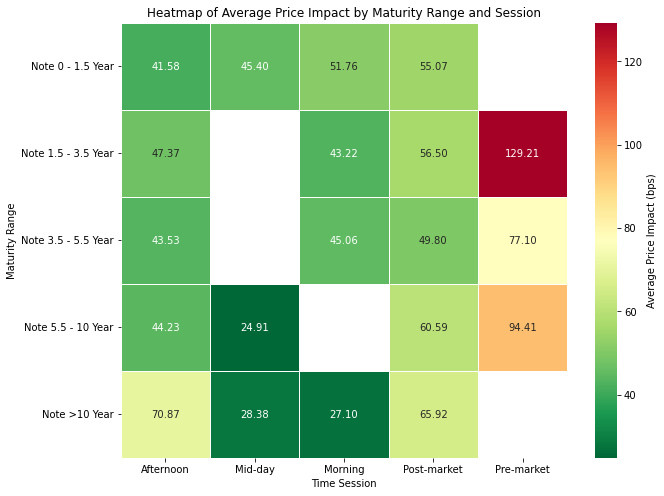

In [198]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the session performance table for the last week of October
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')

# Pivot the DataFrame to get a matrix for the heatmap
price_impact_pivot = last_week_session_performance_oct.pivot(
    index='Maturity Range',
    columns='Original Session',
    values='Avg Price Impact'
)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with green-to-red color map
sns.heatmap(price_impact_pivot, annot=True, cmap="RdYlGn_r", fmt=".2f", linewidths=.5, cbar_kws={'label': 'Average Price Impact (bps)'})

# Customize the plot
plt.title('Heatmap of Average Price Impact by Maturity Range and Session')
plt.xlabel('Time Session')
plt.ylabel('Maturity Range')

# Show the plot
plt.show()

In [200]:
# Set hierarchical index with 'Maturity Range' and 'Original Session'
last_week_session_performance_oct.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance_oct = last_week_session_performance_oct.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance_oct

Original Session  Notional Value  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Pre-market          Afternoon    1.116652e+09   
                    Pre-market            Mid-day    2.128645e+09   
                    Pre-market            Morning    2.754625e+08   
                    Pre-market        Post-market    2.740993e+09   
Note 1.5 - 3.5 Year Mid-day             Afternoon    2.616383e+09   
                    Mid-day               Morning    2.017177e+08   
                    Mid-day           Post-market    1.704730e+09   
                    Mid-day            Pre-market    3.629526e+08   
Note 3.5 - 5.5 Year Mid-day             Afternoon    1.773074e+09   
                    Mid-day               Morning    3.386992e+08   
                    Mid-day           Post-market    9.985012e+08   
                    Mid-day            Pre-market    6.286776e+08   
Note 5.5 - 10 Year  Morning             Afternoon    1.438314e+09   
                    Morning               Mid-day    2.709062e+08   
                    Morning           Post-market    1.073871e+09   
                    Morning            Pre-market    1.929676e+08   
Note >10 Year       Pre-market          Afternoon    1.390396e+09   
                    Pre-market            Mid-day    1.578480e+08   
                    Pre-market            Morning    1.654709e+08   
                    Pre-market        Post-market    1.119985e+09   

                                  Total Accepted Volume  # of Trades  \
Maturity Range      Best Session                                       
Note 0 - 1.5 Year   Pre-market              11166518.59          429   
                    Pre-market              21286450.94          352   
                    Pre-market               2754624.51          415   
                    Pre-market              27409927.42          596   
Note 1.5 - 3.5 Year Mid-day                 26163826.79          328   
                    Mid-day                  2017177.05          467   
                    Mid-day                 17047295.10          642   
                    Mid-day                  3629525.90           78   
Note 3.5 - 5.5 Year Mid-day                 17730739.88          223   
                    Mid-day                  3386991.57          331   
                    Mid-day                  9985011.50          418   
                    Mid-day                  6286776.31           75   
Note 5.5 - 10 Year  Morning                 14383135.28          313   
                    Morning                  2709062.40          320   
                    Morning                 10738708.85          467   
                    Morning                  1929675.70           46   
Note >10 Year       Pre-market              13903958.96          353   
                    Pre-market               1578479.51          232   
                    Pre-market               1654709.26          336   
                    Pre-market              11199852.63          587   

                                  Avg Price Impact  Volume Weighted Slippage  \
Maturity Range      Best Session                                               
Note 0 - 1.5 Year   Pre-market           41.581108                  0.001312   
                    Pre-market           45.395001                  0.001172   
                    Pre-market           51.764256                  0.018938   
                    Pre-market           55.074902                  0.004447   
Note 1.5 - 3.5 Year Mid-day              47.370633                  0.002928   
                    Mid-day              43.216901                  0.003350   
                    Mid-day              56.502244                  0.003053   
                    Mid-day             129.208801                 -0.000663   
Note 3.5 - 5.5 Year Mid-day              43.532649                  0.016300   
                    Mid-day              45.06142

In [239]:
# Rank the cost saving values within each Maturity Range in descending order
last_week_session_performance_oct['Cost Saving Rank'] = last_week_session_performance_oct.groupby('Maturity Range')['Cost Saving ($)'].rank(ascending=False)

# Sort the table by Maturity Range and Cost Saving Rank if you want to display it in ranked order
last_week_session_performance_oct_sorted = last_week_session_performance_oct.sort_values(by=['Maturity Range', 'Cost Saving Rank'])

# Display the ranked table
last_week_session_performance_oct_sorted

,Maturity Range,Original Session,Best Session,Notional Value,Total Accepted Volume,# of Trades,Avg Price Impact,Volume Weighted Slippage,Dealer Count,Transferred Volume,Cost Saving ($),Cost Saving Rank
3,Note 0 - 1.5 Year,Post-market,Pre-market,2.740993e+09,27409927.42,596,55.074902,0.004447,19,5.481985e+06,37157.488015,1.0
2,Note 0 - 1.5 Year,Morning,Pre-market,2.754625e+08,2754624.51,415,51.764256,0.018938,18,5.509249e+05,16215.293910,2.0
1,Note 0 - 1.5 Year,Mid-day,Pre-market,2.128645e+09,21286450.94,352,45.395001,0.001172,19,4.257290e+06,7994.708500,3.0
0,Note 0 - 1.5 Year,Afternoon,Pre-market,1.116652e+09,11166518.59,429,41.581108,0.001312,19,2.233304e+06,4794.033591,4.0
4,Note 1.5 - 3.5 Year,Afternoon,Mid-day,2.616383e+09,26163826.79,328,47.370633,0.002928,19,8.721276e+06,58305.681598,1.0
6,Note 1.5 - 3.5 Year,Post-market,Mid-day,1.704730e+09,17047295.10,642,56.502244,0.003053,18,5.682432e+06,46059.832843,2.0
5,Note 1.5 - 3.5 Year,Morning,Mid-day,2.017177e+08,2017177.05,467,43.216901,0.003350,18,6.723923e+05,4666.634432,3.0
7,Note 1.5 - 3.5 Year,Pre-market,Mid-day,3.629526e+08,3629525.90,78,129.208801,-0.000663,15,1.209842e+06,3784.011948,4.0
8,Note 3.5 - 5.5 Year,Afternoon,Mid-day,1.773074e+09,17730739.88,223,43.532649,0.016300,19,5.910247e+06,167852.017314,1.0
10,Note 3.5 - 5.5 Year,Post-market,Mid-day,9.985012e+08,9985011.50,418,49.799470,0.005179,18,3.328337e+06,37311.902352,2.0


In [241]:
last_week_session_performance_oct_sorted.columns

Index(['Maturity Range', 'Original Session', 'Best Session', 'Notional Value',
       'Total Accepted Volume', '# of Trades', 'Avg Price Impact',
       'Volume Weighted Slippage', 'Dealer Count', 'Transferred Volume',
       'Cost Saving ($)', 'Cost Saving Rank'],
      dtype='object')

In [ ]:
last_week_session_performance_oct_sorted[['Original Session', 'Notional Value', 'Total Accepted Volume',
       '# of Trades', 'Avg Price Impact', 'Volume Weighted Slippage',
       'Dealer Count', 'Transferred Volume', 'Cost Saving ($)']]

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/last_week_session_performance_oct.csv'

# Save the DataFrame to a CSV file
last_week_session_performance_oct.to_csv(file_path)

In [243]:
sum_of_savings = last_week_session_performance_oct.groupby('Maturity Range')['Cost Saving ($)'].sum()
total_notion = last_week_session_performance_oct.groupby('Maturity Range')['Notional Value'].sum()

# Display the resulting sums
sum_of_savings.sum()

872579.9458887316

In [245]:
total_notion

Maturity Range
Note 0 - 1.5 Year      6.261752e+09
Note 1.5 - 3.5 Year    4.885782e+09
Note 3.5 - 5.5 Year    3.738952e+09
Note 5.5 - 10 Year     2.976058e+09
Note >10 Year          2.833700e+09
Name: Notional Value, dtype: float64

In [247]:
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
# Set hierarchical index with 'Maturity Range' and 'Original Session'
last_week_session_performance_dec.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance_dec = last_week_session_performance_dec.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance_dec

Original Session  Notional Value  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Morning             Afternoon    5.238062e+07   
                    Morning               Mid-day    2.672228e+09   
                    Morning           Post-market    9.700020e+07   
                    Morning            Pre-market    2.823067e+08   
Note 1.5 - 3.5 Year Pre-market          Afternoon    6.815985e+07   
                    Pre-market            Mid-day    2.832840e+09   
                    Pre-market            Morning    1.106334e+09   
                    Pre-market        Post-market    1.191335e+08   
Note 3.5 - 5.5 Year Afternoon             Mid-day    1.537405e+09   
                    Afternoon             Morning    2.774375e+08   
                    Afternoon         Post-market    6.182412e+07   
                    Afternoon          Pre-market    1.206011e+08   
Note 5.5 - 10 Year  Afternoon             Mid-day    2.475422e+09   
                    Afternoon             Morning    4.583814e+08   
                    Afternoon         Post-market    1.714657e+08   
                    Afternoon          Pre-market    5.774372e+07   
Note >10 Year       Afternoon             Mid-day    9.923625e+08   
                    Afternoon             Morning    5.780937e+07   
                    Afternoon         Post-market    7.808714e+07   
                    Afternoon          Pre-market    6.982837e+07   

                                  Total Accepted Volume  # of Trades  \
Maturity Range      Best Session                                       
Note 0 - 1.5 Year   Morning                   523806.20           91   
                    Morning                 26722282.05          402   
                    Morning                   970001.98          187   
                    Morning                  2823067.16           54   
Note 1.5 - 3.5 Year Pre-market                681598.50           95   
                    Pre-market              28328399.20          372   
                    Pre-market              11063343.05          561   
                    Pre-market               1191335.40          241   
Note 3.5 - 5.5 Year Afternoon               15374048.30          222   
                    Afternoon                2774375.06          328   
                    Afternoon                 618241.20          129   
                    Afternoon                1206010.70           20   
Note 5.5 - 10 Year  Afternoon               24754216.25          306   
                    Afternoon                4583814.30          310   
                    Afternoon                1714656.80          144   
                    Afternoon                 577437.20           24   
Note >10 Year       Afternoon                9923624.71          288   
                    Afternoon                 578093.70          312   
                    Afternoon                 780871.40          205   
                    Afternoon                 698283.70           25   

                                  Avg Price Impact  Volume Weighted Slippage  \
Maturity Range      Best Session                                               
Note 0 - 1.5 Year   Morning              25.683811                  0.000868   
                    Morning              47.712374                  0.007695   
                    Morning              26.195789                 -0.002375   
                    Morning              73.758348                 -0.000046   
Note 1.5 - 3.5 Year Pre-market           32.611868                 -0.000140   
                    Pre-market           38.860854                  0.006735   
                    Pre-market           36.016358                  0.002441   
                    Pre-market           34.650295                  0.001607   
Note 3.5 - 5.5 Year Afternoon            38.490469                  0.000096   
                    Afternoon            34.81198

In [249]:
# Rank the cost saving values within each Maturity Range in descending order
last_week_session_performance_dec['Cost Saving Rank'] = last_week_session_performance_dec.groupby('Maturity Range')['Cost Saving ($)'].rank(ascending=False)

# Sort the table by Maturity Range and Cost Saving Rank if you want to display it in ranked order
last_week_session_performance_dec_sorted = last_week_session_performance_dec.sort_values(by=['Maturity Range', 'Cost Saving Rank'])

# Display the ranked table
last_week_session_performance_dec_sorted

Original Session  Notional Value  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Morning               Mid-day    2.672228e+09   
                    Morning            Pre-market    2.823067e+08   
                    Morning           Post-market    9.700020e+07   
                    Morning             Afternoon    5.238062e+07   
Note 1.5 - 3.5 Year Pre-market            Mid-day    2.832840e+09   
                    Pre-market            Morning    1.106334e+09   
                    Pre-market        Post-market    1.191335e+08   
                    Pre-market          Afternoon    6.815985e+07   
Note 3.5 - 5.5 Year Afternoon             Mid-day    1.537405e+09   
                    Afternoon          Pre-market    1.206011e+08   
                    Afternoon             Morning    2.774375e+08   
                    Afternoon         Post-market    6.182412e+07   
Note 5.5 - 10 Year  Afternoon             Mid-day    2.475422e+09   
                    Afternoon             Morning    4.583814e+08   
                    Afternoon         Post-market    1.714657e+08   
                    Afternoon          Pre-market    5.774372e+07   
Note >10 Year       Afternoon             Mid-day    9.923625e+08   
                    Afternoon          Pre-market    6.982837e+07   
                    Afternoon         Post-market    7.808714e+07   
                    Afternoon             Morning    5.780937e+07   

                                  Total Accepted Volume  # of Trades  \
Maturity Range      Best Session                                       
Note 0 - 1.5 Year   Morning                 26722282.05          402   
                    Morning                  2823067.16           54   
                    Morning                   970001.98          187   
                    Morning                   523806.20           91   
Note 1.5 - 3.5 Year Pre-market              28328399.20          372   
                    Pre-market              11063343.05          561   
                    Pre-market               1191335.40          241   
                    Pre-market                681598.50           95   
Note 3.5 - 5.5 Year Afternoon               15374048.30          222   
                    Afternoon                1206010.70           20   
                    Afternoon                2774375.06          328   
                    Afternoon                 618241.20          129   
Note 5.5 - 10 Year  Afternoon               24754216.25          306   
                    Afternoon                4583814.30          310   
                    Afternoon                1714656.80          144   
                    Afternoon                 577437.20           24   
Note >10 Year       Afternoon                9923624.71          288   
                    Afternoon                 698283.70           25   
                    Afternoon                 780871.40          205   
                    Afternoon                 578093.70          312   

                                  Avg Price Impact  Volume Weighted Slippage  \
Maturity Range      Best Session                                               
Note 0 - 1.5 Year   Morning              47.712374                  0.007695   
                    Morning              73.758348                 -0.000046   
                    Morning              26.195789                 -0.002375   
                    Morning              25.683811                  0.000868   
Note 1.5 - 3.5 Year Pre-market           38.860854                  0.006735   
                    Pre-market           36.016358                  0.002441   
                    Pre-market           34.650295                  0.001607   
                    Pre-market           32.611868                 -0.000140   
Note 3.5 - 5.5 Year Afternoon            38.490469                  0.000096   
                    Afternoon            75.96383

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/last_week_session_performance_dec.csv'

# Save the DataFrame to a CSV file
last_week_session_performance_dec.to_csv(file_path)

In [ ]:
sum_of_savings = last_week_session_performance_dec.groupby('Maturity Range')['Cost Saving ($)'].sum()
total_notion = last_week_session_performance_dec.groupby('Maturity Range')['Notional Value'].sum()

# Display the resulting sums
sum_of_savings.sum()

In [ ]:
total_notion

# optimal sizing under the last week analysis

In [251]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_last_week_session_performance(group1, df_it, month):
    # Filter data for the specified month only
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Filter only for the last week of the specified month
    last_week_data = group1[(group1['Year_Month'] == month) & (group1['Week_Group'] == 'Last_Week')]

    # Add Time_Session to df_it for grouping purposes
    df_it['Time_Session'] = df_it.index.map(assign_time_session)

    # Define volume group based on quantiles of `ACCEPTEDVOL` in `last_week_data`
    last_week_data['Volume_Group'] = pd.qcut(last_week_data['ACCEPTEDVOL'], 3, labels=['Low', 'Medium', 'High'])

    # Calculate metrics for each session and maturity range in `last_week_data`
    volume_weighted_slippage = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session', 'Volume_Group']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')

    notional_value = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session', 'Volume_Group'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session', 'Volume_Group'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session', 'Volume_Group'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session', 'Volume_Group']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact without `Volume_Group` in `df_it`
    avg_price_impact = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['price impact (bps)'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades
    }).reset_index()

    # Merge `avg_price_impact` without `Volume_Group`
    combined_data = combined_data.merge(avg_price_impact, on=['MATURITY_RANGE', 'Time_Session'], how='left')

    # Identify best and worst sessions based on slippage within each maturity range and volume group
    best_sessions = combined_data.loc[combined_data.groupby(['MATURITY_RANGE', 'Volume_Group'])['Volume_Weighted_Slippage'].idxmin()]
    worst_sessions = combined_data.loc[combined_data.groupby(['MATURITY_RANGE', 'Volume_Group'])['Volume_Weighted_Slippage'].idxmax()]

    # Calculate the transferrable volume and savings if 1/3 of the volume from the worst session is transferred to the best session
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        for volume_group in ['Low', 'Medium', 'High']:
            maturity_data = combined_data[(combined_data['MATURITY_RANGE'] == maturity) & (combined_data['Volume_Group'] == volume_group)]
            best_session = best_sessions[(best_sessions['MATURITY_RANGE'] == maturity) & (best_sessions['Volume_Group'] == volume_group)]
            worst_session = worst_sessions[(worst_sessions['MATURITY_RANGE'] == maturity) & (worst_sessions['Volume_Group'] == volume_group)]

            if not best_session.empty and not worst_session.empty:
                # Calculate transferrable volume
                transferrable_volume = worst_session['Total_Accepted_Volume'].values[0] * (1 / 5)

                # Calculate slippage difference and price impact ratio
                slippage_diff = worst_session['Volume_Weighted_Slippage'].values[0] - best_session['Volume_Weighted_Slippage'].values[0]
                bad_impact = worst_session['Avg_Price_Impact'].values[0]
                good_impact = best_session['Avg_Price_Impact'].values[0]
                impact_ratio = (bad_impact - good_impact) / good_impact

                # Calculate savings with the impact ratio applied
                savings = transferrable_volume * slippage_diff * (1 + abs(impact_ratio))

                savings_data.append({
                    'Maturity Range': maturity,
                    'Volume Group': volume_group,
                    'Original Session (Worst)': worst_session['Time_Session'].values[0],
                    'Best Session': best_session['Time_Session'].values[0],
                    'Notional Value': worst_session['Notional_Value'].values[0],
                    'Total Accepted Volume': worst_session['Total_Accepted_Volume'].values[0],
                    'Num_of_Trades': worst_session['Num_of_Trades'].values[0],
                    'Avg Price Impact': worst_session['Avg_Price_Impact'].values[0],
                    'Volume Weighted Slippage (Worst)': worst_session['Volume_Weighted_Slippage'].values[0],
                    'Dealer Count': worst_session['Dealer_Count'].values[0],
                    'Transferred Volume': transferrable_volume,
                    'Cost Saving ($)': savings
                })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    return savings_df

# Generate session performance table for the last week of October
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')

In [253]:
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')
last_week_session_performance_oct[['Maturity Range', 'Original Session (Worst)', 'Best Session', 'Notional Value',
       'Total Accepted Volume', 'Num_of_Trades', 'Avg Price Impact', 'Volume Weighted Slippage (Worst)',
       'Transferred Volume', 'Cost Saving ($)']]

,Maturity Range,Original Session (Worst),Best Session,Notional Value,Total Accepted Volume,Num_of_Trades,Avg Price Impact,Volume Weighted Slippage (Worst),Transferred Volume,Cost Saving ($)
0,Note 0 - 1.5 Year,Pre-market,Mid-day,2.222000e+04,222.20,4,116.226222,-0.008976,44.440,0.100403
1,Note 0 - 1.5 Year,Pre-market,Morning,6.283210e+05,6283.21,16,116.226222,0.023897,1256.642,90.093316
2,Note 0 - 1.5 Year,Morning,Pre-market,2.708860e+08,2708860.40,63,51.764256,0.019397,541772.080,16372.281527
3,Note 1.5 - 3.5 Year,Morning,Pre-market,7.049800e+05,7049.80,292,43.216901,-0.010860,1409.960,20.567588
4,Note 1.5 - 3.5 Year,Afternoon,Post-market,4.080299e+06,40802.99,99,47.370633,-0.009335,8160.598,22.136189
5,Note 1.5 - 3.5 Year,Morning,Pre-market,1.971899e+08,1971898.75,45,43.216901,0.003662,394379.750,2803.532232
6,Note 3.5 - 5.5 Year,Pre-market,Morning,5.050000e+03,50.50,1,77.103143,-0.003738,10.100,0.178995
7,Note 3.5 - 5.5 Year,Morning,Pre-market,2.504598e+06,25045.98,79,45.061429,-0.010826,5009.196,26.359724
8,Note 3.5 - 5.5 Year,Afternoon,Mid-day,1.769484e+09,17694844.48,80,43.532649,0.016356,3538968.896,102901.389476
9,Note 5.5 - 10 Year,Post-market,Afternoon,5.050000e+03,50.50,1,60.590069,-0.003706,10.100,0.185817


In [255]:
# Rank the cost saving values within each Maturity Range in descending order
last_week_session_performance_oct['Cost Saving Rank'] = last_week_session_performance_oct.groupby('Maturity Range')['Cost Saving ($)'].rank(ascending=False)
last_week_session_performance_oct.set_index(['Maturity Range', 'Best Session'], inplace=True)
# Sort the table by Maturity Range and Cost Saving Rank if you want to display it in ranked order
last_week_session_performance_oct_sorted = last_week_session_performance_oct.sort_values(by=['Maturity Range', 'Cost Saving Rank'])

# Display the ranked table
last_week_session_performance_oct_sorted

Volume Group Original Session (Worst)  \
Maturity Range      Best Session                                         
Note 0 - 1.5 Year   Pre-market           High                  Morning   
                    Morning            Medium               Pre-market   
                    Mid-day               Low               Pre-market   
Note 1.5 - 3.5 Year Pre-market           High                  Morning   
                    Post-market        Medium                Afternoon   
                    Pre-market            Low                  Morning   
Note 3.5 - 5.5 Year Mid-day              High                Afternoon   
                    Pre-market         Medium                  Morning   
                    Morning               Low               Pre-market   
Note 5.5 - 10 Year  Morning              High                Afternoon   
                    Pre-market         Medium                Afternoon   
                    Afternoon             Low              Post-market   
Note >10 Year       Pre-market           High                Afternoon   
                    Pre-market         Medium              Post-market   
                    Afternoon             Low                  Mid-day   

                                  Notional Value  Total Accepted Volume  \
Maturity Range      Best Session                                          
Note 0 - 1.5 Year   Pre-market      2.708860e+08             2708860.40   
                    Morning         6.283210e+05                6283.21   
                    Mid-day         2.222000e+04                 222.20   
Note 1.5 - 3.5 Year Pre-market      1.971899e+08             1971898.75   
                    Post-market     4.080299e+06               40802.99   
                    Pre-market      7.049800e+05                7049.80   
Note 3.5 - 5.5 Year Mid-day         1.769484e+09            17694844.48   
                    Pre-market      2.504598e+06               25045.98   
                    Morning         5.050000e+03                  50.50   
Note 5.5 - 10 Year  Morning         1.434033e+09            14340327.44   
                    Pre-market      3.914154e+06               39141.54   
                    Afternoon       5.050000e+03                  50.50   
Note >10 Year       Pre-market      1.387123e+09            13871231.93   
                    Pre-market      1.149683e+07              114968.30   
                    Afternoon       3.817800e+05                3817.80   

                                  Num_of_Trades  Avg Price Impact  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Pre-market               63         51.764256   
                    Morning                  16        116.226222   
                    Mid-day                   4        116.226222   
Note 1.5 - 3.5 Year Pre-market               45         43.216901   
                    Post-market              99         47.370633   
                    Pre-market              292         43.216901   
Note 3.5 - 5.5 Year Mid-day                  80         43.532649   
                    Pre-market               79         45.061429   
                    Morning                   1         77.103143   
Note 5.5 - 10 Year  Morning                 110         44.228746   
                    Pre-market               78         44.228746   
                    Afternoon                 1         60.590069   
Note >10 Year       Pre-market              110         70.870972   
                    Pre-market              131         65.921551   
                    Afternoon               140         28.382356   

                                  Volume Weighted Slippage (Worst)  \
Maturity Range      Best Session                                     
Note 0 - 1.5 Year   Pre-market                            0.019397   
                    Morning                               0.023897   
                    Mid-day                 

In [257]:
(last_week_session_performance_oct['Transferred Volume']* 100).sum()

1016491916.4000001

In [259]:
last_week_session_performance_oct['Cost Saving ($)'].sum()

475601.75935623795

In [261]:
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
last_week_session_performance_dec[['Maturity Range', 'Original Session (Worst)', 'Best Session', 'Notional Value',
       'Total Accepted Volume', 'Num_of_Trades', 'Avg Price Impact', 'Volume Weighted Slippage (Worst)',
       'Transferred Volume', 'Cost Saving ($)']]


,Maturity Range,Original Session (Worst),Best Session,Notional Value,Total Accepted Volume,Num_of_Trades,Avg Price Impact,Volume Weighted Slippage (Worst),Transferred Volume,Cost Saving ($)
0,Note 0 - 1.5 Year,Afternoon,Mid-day,8.080000e+04,808.00,18,25.683811,-0.001126,161.600,1.069792e+00
1,Note 0 - 1.5 Year,Pre-market,Post-market,5.120700e+05,5120.70,10,73.758348,-0.002082,1024.140,1.262371e+01
2,Note 0 - 1.5 Year,Mid-day,Morning,2.663956e+09,26639563.05,215,47.712374,0.007730,5327912.610,1.775890e+06
3,Note 1.5 - 3.5 Year,Pre-market,Post-market,5.050000e+03,50.50,1,96.997566,-0.007644,10.100,2.208845e-01
4,Note 1.5 - 3.5 Year,Pre-market,Afternoon,6.383200e+05,6383.20,12,96.997566,-0.007626,1276.640,9.664815e+00
5,Note 1.5 - 3.5 Year,Mid-day,Pre-market,2.826938e+09,28269384.90,185,38.860854,0.006768,5653876.980,7.327056e+04
6,Note 3.5 - 5.5 Year,Morning,Post-market,5.555000e+05,5555.00,192,34.811982,-0.014909,1111.000,5.669870e+00
7,Note 3.5 - 5.5 Year,Pre-market,Morning,4.120800e+05,4120.80,8,75.963830,-0.007848,824.160,1.023742e+01
8,Note 3.5 - 5.5 Year,Mid-day,Afternoon,1.534143e+09,15341425.30,106,38.490469,0.000117,3068285.060,2.801591e+04
9,Note 5.5 - 10 Year,Post-market,Morning,8.080000e+03,80.80,1,47.615889,0.002153,16.160,3.545575e-01


In [263]:
# Rank the cost saving values within each Maturity Range in descending order
last_week_session_performance_dec['Cost Saving Rank'] = last_week_session_performance_dec.groupby('Maturity Range')['Cost Saving ($)'].rank(ascending=False)
last_week_session_performance_dec.set_index(['Maturity Range', 'Best Session'], inplace=True)
# Sort the table by Maturity Range and Cost Saving Rank if you want to display it in ranked order
last_week_session_performance_dec_sorted = last_week_session_performance_dec.sort_values(by=['Maturity Range', 'Cost Saving Rank'])

# Display the ranked table
last_week_session_performance_dec_sorted

Volume Group Original Session (Worst)  \
Maturity Range      Best Session                                         
Note 0 - 1.5 Year   Morning              High                  Mid-day   
                    Post-market        Medium               Pre-market   
                    Mid-day               Low                Afternoon   
Note 1.5 - 3.5 Year Pre-market           High                  Mid-day   
                    Afternoon          Medium               Pre-market   
                    Post-market           Low               Pre-market   
Note 3.5 - 5.5 Year Afternoon            High                  Mid-day   
                    Morning            Medium               Pre-market   
                    Post-market           Low                  Morning   
Note 5.5 - 10 Year  Afternoon            High                  Mid-day   
                    Pre-market         Medium                  Morning   
                    Morning               Low              Post-market   
Note >10 Year       Afternoon            High                  Mid-day   
                    Pre-market         Medium              Post-market   
                    Morning               Low              Post-market   

                                  Notional Value  Total Accepted Volume  \
Maturity Range      Best Session                                          
Note 0 - 1.5 Year   Morning         2.663956e+09            26639563.05   
                    Post-market     5.120700e+05                5120.70   
                    Mid-day         8.080000e+04                 808.00   
Note 1.5 - 3.5 Year Pre-market      2.826938e+09            28269384.90   
                    Afternoon       6.383200e+05                6383.20   
                    Post-market     5.050000e+03                  50.50   
Note 3.5 - 5.5 Year Afternoon       1.534143e+09            15341425.30   
                    Morning         4.120800e+05                4120.80   
                    Post-market     5.555000e+05                5555.00   
Note 5.5 - 10 Year  Afternoon       2.469631e+09            24696312.95   
                    Pre-market      2.147260e+06               21472.60   
                    Morning         8.080000e+03                  80.80   
Note >10 Year       Afternoon       9.862126e+08             9862125.81   
                    Pre-market      1.013636e+07              101363.60   
                    Morning         9.090000e+03                  90.90   

                                  Num_of_Trades  Avg Price Impact  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Morning                 215         47.712374   
                    Post-market              10         73.758348   
                    Mid-day                  18         25.683811   
Note 1.5 - 3.5 Year Pre-market              185         38.860854   
                    Afternoon                12         96.997566   
                    Post-market               1         96.997566   
Note 3.5 - 5.5 Year Afternoon               106         38.490469   
                    Morning                   8         75.963830   
                    Post-market             192         34.811982   
Note 5.5 - 10 Year  Afternoon               148         37.363802   
                    Pre-market               54         37.520947   
                    Morning                   1         47.615889   
Note >10 Year       Afternoon               129         23.344859   
                    Pre-market              139         66.174234   
                    Morning                   2         66.174234   

                                  Volume Weighted Slippage (Worst)  \
Maturity Range      Best Session                                     
Note 0 - 1.5 Year   Morning                               0.007730   
                    Post-market                          -0.002082   
                    Mid-day                 

In [311]:

file_path = '/Users/jiangzixuan/Desktop/last_week_session_performance_dec.csv'

# Save the DataFrame as a CSV
last_week_session_performance_dec_sorted.to_csv(file_path, index=False)

In [313]:
file_path = '/Users/jiangzixuan/Desktop/last_week_session_performance_oct.csv'

# Save the DataFrame as a CSV
last_week_session_performance_oct_sorted.to_csv(file_path, index=False)

In [265]:
(last_week_session_performance_dec['Transferred Volume']* 100).sum()

2099077162.2

In [267]:
last_week_session_performance_dec['Cost Saving ($)'].sum()

2069319.8926206406

In [269]:
last_week_session_performance_oct.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance__volume_oct = last_week_session_performance_oct.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance__volume_oct

KeyError: "None of ['Maturity Range', 'Best Session'] are in the columns"

In [271]:
last_week_session_performance__volume_oct['Transferred Volume'].sum() * 100

NameError: name 'last_week_session_performance__volume_oct' is not defined

In [273]:
last_week_session_performance__volume_oct['Cost Saving ($)'].sum()

NameError: name 'last_week_session_performance__volume_oct' is not defined

In [275]:
# Specify the path where you want to save the file
file_path = '/content/last_week_session_performance__volume_oct.csv'

# Save the DataFrame to a CSV file
last_week_session_performance__volume_oct.to_csv(file_path)

NameError: name 'last_week_session_performance__volume_oct' is not defined

In [277]:
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
print(last_week_session_performance_dec['Cost Saving ($)'].sum())
last_week_session_performance_dec.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance__volume_dec = last_week_session_performance_dec.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance__volume_dec

2069319.8926206406


Volume Group Original Session (Worst)  \
Maturity Range      Best Session                                         
Note 0 - 1.5 Year   Mid-day               Low                Afternoon   
                    Morning              High                  Mid-day   
                    Post-market        Medium               Pre-market   
Note 1.5 - 3.5 Year Afternoon          Medium               Pre-market   
                    Post-market           Low               Pre-market   
                    Pre-market           High                  Mid-day   
Note 3.5 - 5.5 Year Afternoon            High                  Mid-day   
                    Morning            Medium               Pre-market   
                    Post-market           Low                  Morning   
Note 5.5 - 10 Year  Afternoon            High                  Mid-day   
                    Morning               Low              Post-market   
                    Pre-market         Medium                  Morning   
Note >10 Year       Afternoon            High                  Mid-day   
                    Morning               Low              Post-market   
                    Pre-market         Medium              Post-market   

                                  Notional Value  Total Accepted Volume  \
Maturity Range      Best Session                                          
Note 0 - 1.5 Year   Mid-day         8.080000e+04                 808.00   
                    Morning         2.663956e+09            26639563.05   
                    Post-market     5.120700e+05                5120.70   
Note 1.5 - 3.5 Year Afternoon       6.383200e+05                6383.20   
                    Post-market     5.050000e+03                  50.50   
                    Pre-market      2.826938e+09            28269384.90   
Note 3.5 - 5.5 Year Afternoon       1.534143e+09            15341425.30   
                    Morning         4.120800e+05                4120.80   
                    Post-market     5.555000e+05                5555.00   
Note 5.5 - 10 Year  Afternoon       2.469631e+09            24696312.95   
                    Morning         8.080000e+03                  80.80   
                    Pre-market      2.147260e+06               21472.60   
Note >10 Year       Afternoon       9.862126e+08             9862125.81   
                    Morning         9.090000e+03                  90.90   
                    Pre-market      1.013636e+07              101363.60   

                                  Num_of_Trades  Avg Price Impact  \
Maturity Range      Best Session                                    
Note 0 - 1.5 Year   Mid-day                  18         25.683811   
                    Morning                 215         47.712374   
                    Post-market              10         73.758348   
Note 1.5 - 3.5 Year Afternoon                12         96.997566   
                    Post-market               1         96.997566   
                    Pre-market              185         38.860854   
Note 3.5 - 5.5 Year Afternoon               106         38.490469   
                    Morning                   8         75.963830   
                    Post-market             192         34.811982   
Note 5.5 - 10 Year  Afternoon               148         37.363802   
                    Morning                   1         47.615889   
                    Pre-market               54         37.520947   
Note >10 Year       Afternoon               129         23.344859   
                    Morning                   2         66.174234   
                    Pre-market              139         66.174234   

                                  Volume Weighted Slippage (Worst)  \
Maturity Range      Best Session                                     
Note 0 - 1.5 Year   Mid-day                              -0.001126   
                    Morning                               0.007730   
                    Post-market             

In [ ]:
last_week_session_performance__volume_dec['Transferred Volume'].sum() * 100

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/last_week_session_performance__volume_dec.csv'

# Save the DataFrame to a CSV file
last_week_session_performance__volume_dec.to_csv(file_path)

In [ ]:
df_it.columns

In [279]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_last_week_session_performance(group1, df_it, month):
    # Filter data for the specified month only
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Filter only for the last week of the specified month
    last_week_data = group1[(group1['Year_Month'] == month) & (group1['Week_Group'] == 'Last_Week')]

    # Add Time_Session to df_it for grouping purposes
    df_it['Time_Session'] = df_it.index.map(assign_time_session)

    # Calculate average limit volume based on previous data
    avg_limit_volume = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['Optimal_Q_t'].mean().rename('Avg_Limit_Volume')

    # Group by Maturity Range and Time Session for analysis
    volume_weighted_slippage = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')

    notional_value = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact
    avg_price_impact = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['I_t'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Merge average limit volume into the combined data for reference
    combined_data = combined_data.merge(avg_limit_volume, on=['MATURITY_RANGE', 'Time_Session'], how='left')

    # Identify the best session within each maturity range (lowest slippage)
    best_sessions = combined_data.loc[combined_data.groupby('MATURITY_RANGE')['Volume_Weighted_Slippage'].idxmin()]

    # Calculate the transferrable volume and savings for each session only if sessions differ
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]
        best_session = best_sessions[best_sessions['MATURITY_RANGE'] == maturity]

        for _, row in maturity_data.iterrows():
            if row['Time_Session'] != best_session['Time_Session'].values[0]:
                # Limit the transfer fraction to realistic values (e.g., no more than 50%)
                avg_price_impact_best = best_session['Avg_Price_Impact'].values[0]
                if avg_price_impact_best < 20:
                    transfer_fraction = 3/4  # Max of 50%
                elif 20 <= avg_price_impact_best <= 50:
                    transfer_fraction = 2/ 3
                elif 50 < avg_price_impact_best <= 80:
                    transfer_fraction = 1 / 3
                else:
                    transfer_fraction = 1 / 4

                # Calculate transferrable volume and savings based on the capped transfer fraction
                transferrable_volume = row['Avg_Limit_Volume'] * transfer_fraction
                optimal_notional_value = row['Notional_Value'] * (transferrable_volume / row['Total_Accepted_Volume'])
                slippage_diff = row['Volume_Weighted_Slippage'] - best_session['Volume_Weighted_Slippage'].values[0]
                savings = transferrable_volume * slippage_diff * row['Num_of_Trades']

                savings_data.append({
                    'Maturity Range': maturity,
                    'Original Session': row['Time_Session'],
                    'Best Session': best_session['Time_Session'].values[0],
                    'Notional Value': row['Notional_Value'],
                    'Optimal Notional Value': optimal_notional_value,
                    'Total Accepted Volume': row['Total_Accepted_Volume'],
                    'Num_of_Trades': row['Num_of_Trades'],
                    'Avg Price Impact': row['Avg_Price_Impact'],
                    'Volume Weighted Slippage': row['Volume_Weighted_Slippage'],
                    'Dealer Count': row['Dealer_Count'],
                    'Transferred Volume': transferrable_volume,
                    'Cost Saving ($)': savings
                })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    return savings_df

In [281]:
# Generate session performance table for the last week of October
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')
last_week_session_performance_oct[['Maturity Range', 'Original Session', 'Best Session', 'Notional Value',
       'Optimal Notional Value', 'Total Accepted Volume', 'Num_of_Trades',
       'Avg Price Impact', 'Volume Weighted Slippage','Transferred Volume', 'Cost Saving ($)']]

KeyError: 'Column not found: I_t'

In [283]:
import pandas as pd

# Ensure `Year_Month` column is defined in both `group1` and `df_it`
group1['Year_Month'] = group1.index.to_period('M').astype(str)
df_it['Year_Month'] = df_it.index.to_period('M').astype(str)

def calculate_last_week_session_performance(group1, df_it, month):
    # Filter data for the specified month only
    group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
    group1['Time_Session'] = group1.index.map(assign_time_session)
    group1['Weighted_Slippage'] = group1['Slippage_dollars'] * group1['ACCEPTEDVOL']
    group1['ACCEPTED_Volume'] = group1['ACCEPTEDVOL']
    group1['Notional_Value'] = group1['ACCEPTEDVOL'] * 100  # Assuming 'Notional_Value' is calculated from 'ACCEPTEDVOL'

    # Filter only for the last week of the specified month
    last_week_data = group1[(group1['Year_Month'] == month) & (group1['Week_Group'] == 'Last_Week')]

    # Add Time_Session to df_it for grouping purposes
    df_it['Time_Session'] = df_it.index.map(assign_time_session)

    # Calculate average limit volume based on previous data
    avg_limit_volume = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['Optimal_Q_t'].mean().rename('Avg_Limit_Volume')

    # Group by Maturity Range and Time Session for analysis
    volume_weighted_slippage = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).apply(
        lambda x: x['Weighted_Slippage'].sum() / x['ACCEPTEDVOL'].abs().sum()
    ).rename('Volume_Weighted_Slippage')

    notional_value = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['Notional_Value'].sum().rename('Notional_Value')
    accepted_volume = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['ACCEPTEDVOL'].sum().rename('Total_Accepted_Volume')
    dealer_count = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session'])['DEALER'].nunique().rename('Dealer_Count')
    num_of_trades = last_week_data.groupby(['MATURITY_RANGE', 'Time_Session']).size().rename('Num_of_Trades')

    # Calculate Average Price Impact
    avg_price_impact = df_it[df_it['Year_Month'] == month].groupby(['MATURITY_RANGE', 'Time_Session'])['I_t'].mean().rename('Avg_Price_Impact')

    # Combine metrics into a DataFrame
    combined_data = pd.DataFrame({
        'Volume_Weighted_Slippage': volume_weighted_slippage,
        'Notional_Value': notional_value,
        'Total_Accepted_Volume': accepted_volume,
        'Dealer_Count': dealer_count,
        'Num_of_Trades': num_of_trades,
        'Avg_Price_Impact': avg_price_impact.abs()
    }).reset_index()

    # Merge average limit volume into the combined data for reference
    combined_data = combined_data.merge(avg_limit_volume, on=['MATURITY_RANGE', 'Time_Session'], how='left')

    # Identify the best session within each maturity range (lowest slippage)
    best_sessions = combined_data.loc[combined_data.groupby('MATURITY_RANGE')['Volume_Weighted_Slippage'].idxmin()]

    # Calculate the transferrable volume and savings for each session only if sessions differ
    savings_data = []
    for maturity in combined_data['MATURITY_RANGE'].unique():
        maturity_data = combined_data[combined_data['MATURITY_RANGE'] == maturity]
        best_session = best_sessions[best_sessions['MATURITY_RANGE'] == maturity]

        for _, row in maturity_data.iterrows():
            if row['Time_Session'] != best_session['Time_Session'].values[0]:
                # Limit the transfer fraction to realistic values
                avg_price_impact_best = best_session['Avg_Price_Impact'].values[0]
                if avg_price_impact_best < 50:
                    transfer_fraction = 3 / 4
                elif 50 <= avg_price_impact_best <= 80:
                    transfer_fraction = 2 / 3
                elif 80 < avg_price_impact_best <= 100:
                    transfer_fraction = 1 / 3
                else:
                    transfer_fraction = 1 / 4

                # Calculate transferrable volume and savings
                transferrable_volume = row['Avg_Limit_Volume'] * transfer_fraction
                optimal_notional_value = row['Notional_Value'] * (transferrable_volume / row['Total_Accepted_Volume'])
                slippage_diff = row['Volume_Weighted_Slippage'] - best_session['Volume_Weighted_Slippage'].values[0]
                savings = transferrable_volume * slippage_diff * row['Num_of_Trades']

                # Append the calculated savings data
                savings_data.append({
                    'Maturity Range': maturity,
                    'Original Session': row['Time_Session'],
                    'Best Session': best_session['Time_Session'].values[0],
                    'Notional Value': row['Notional_Value'],
                    'Optimal Notional Value': optimal_notional_value,
                    'Total Accepted Volume': row['Total_Accepted_Volume'],
                    'Num_of_Trades': row['Num_of_Trades'],
                    'Avg Price Impact': row['Avg_Price_Impact'],
                    'Volume Weighted Slippage': row['Volume_Weighted_Slippage'],
                    'Dealer Count': row['Dealer_Count'],
                    'Transferred Volume': transferrable_volume,
                    'Cost Saving ($)': savings
                })

    # Convert savings data to DataFrame
    savings_df = pd.DataFrame(savings_data)

    # For each maturity range, keep only the row with the highest transferred volume
    highest_transferred_volume_df = savings_df.loc[savings_df.groupby('Maturity Range')['Transferred Volume'].idxmax()]

    return highest_transferred_volume_df

# Generate session performance table for the last week of October with highest transferred volume rows only
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')
last_week_session_performance_oct[['Maturity Range', 'Original Session', 'Best Session', 'Notional Value',
       'Optimal Notional Value', 'Total Accepted Volume', 'Num_of_Trades',
       'Avg Price Impact', 'Volume Weighted Slippage','Transferred Volume', 'Cost Saving ($)']]


KeyError: 'Column not found: I_t'

In [285]:
last_week_session_performance_oct['Cost Saving ($)'].sum()

475601.75935623795

In [287]:
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
last_week_session_performance_dec[['Maturity Range', 'Original Session', 'Best Session', 'Notional Value',
       'Optimal Notional Value', 'Total Accepted Volume', 'Num_of_Trades',
       'Avg Price Impact', 'Volume Weighted Slippage','Transferred Volume', 'Cost Saving ($)']]


KeyError: 'Column not found: I_t'

In [289]:
last_week_session_performance_dec['Cost Saving ($)'].sum()

2069319.8926206406

In [291]:
last_week_session_performance_oct.columns

Index(['Volume Group', 'Original Session (Worst)', 'Notional Value',
       'Total Accepted Volume', 'Num_of_Trades', 'Avg Price Impact',
       'Volume Weighted Slippage (Worst)', 'Dealer Count',
       'Transferred Volume', 'Cost Saving ($)', 'Cost Saving Rank'],
      dtype='object')

In [293]:
last_week_session_performance_oct['Cost Saving ($)'].sum()

475601.75935623795

In [295]:
last_week_session_performance_oct[last_week_session_performance_oct['Maturity Range'] == 'Note 1.5 - 3.5 Year']['Transferred Volume'].sum()


KeyError: 'Maturity Range'

In [ ]:
last_week_session_performance_oct[last_week_session_performance_oct['Maturity Range'] == 'Note 1.5 - 3.5 Year']['Cost Saving ($)'].sum()

In [ ]:
last_week_session_performance_oct = calculate_last_week_session_performance(group1, df_it, '2023-10')
# Set hierarchical index with 'Maturity Range' and 'Original Session'
last_week_session_performance_oct.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance_oct = last_week_session_performance_oct.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance_oct

In [ ]:
last_week_session_performance_oct.sum()

In [ ]:
last_week_session_performance_oct['Optimal Notional Value'].sum() - last_week_session_performance_oct['Notional Value'].sum()

In [ ]:
# Generate session performance table for the last week of October
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
last_week_session_performance_dec[['Maturity Range', 'Original Session', 'Best Session', 'Notional Value',
       'Optimal Notional Value', 'Total Accepted Volume', 'Num_of_Trades',
       'Avg Price Impact', 'Volume Weighted Slippage','Transferred Volume', 'Cost Saving ($)']]

In [ ]:
last_week_session_performance_dec['Cost Saving ($)'].sum()

In [301]:
last_week_session_performance_dec[last_week_session_performance_dec['Maturity Range'] == 'Note 1.5 - 3.5 Year']['Transferred Volume'].sum()

KeyError: 'Maturity Range'

In [ ]:
last_week_session_performance_dec[last_week_session_performance_dec['Maturity Range'] == 'Note 1.5 - 3.5 Year']['Cost Saving ($)'].sum()

In [297]:
last_week_session_performance_dec = calculate_last_week_session_performance(group1, df_it, '2023-12')
# Set hierarchical index with 'Maturity Range' and 'Original Session'
last_week_session_performance_dec.set_index(['Maturity Range', 'Best Session'], inplace=True)

# Sort the index to ensure proper order within each 'Maturity Range'
last_week_session_performance_dec = last_week_session_performance_dec.sort_index(level=['Maturity Range', 'Best Session'])

# Display the adjusted table with the new index
last_week_session_performance_dec

KeyError: 'Column not found: I_t'

In [299]:
last_week_session_performance_dec['Optimal Notional Value'].sum() - last_week_session_performance_dec['Notional Value'].sum()

KeyError: 'Optimal Notional Value'

# Dealers

## Dashboard 3

In [ ]:
# import pandas as pd

# def reconstruct_table(group1, df_it, month):
#     # Step 1: Define necessary columns in `group1`
#     group1['Year_Month'] = group1.index.to_period('M').astype(str)
#     group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
#     group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

#     # Filter data for the specified month
#     group1_month = group1[group1['Year_Month'] == month].copy()
#     df_it_month = df_it[df_it.index.to_period('M') == month].copy()

#     # Join with `df_it` for price impact calculations
#     group1_month = group1_month.join(df_it_month[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

#     # Step 2: Group by maturity range and dealer
#     metrics = group1_month.groupby(['MATURITY_RANGE', 'DEALER']).agg(
#         Total_Notional_Value=('Notional_Value', 'sum'),
#         Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
#         Num_of_Trades=('DEALER', 'nunique'),  # Assuming `TRADE_ID` is unique for each trade
#         Avg_Price_Impact=('I_t', 'mean'),
#         Volume_Weighted_Slippage=('Weighted_Slippage', lambda x: x.sum() / group1_month['ACCEPTEDVOL'].abs().sum()),
#     ).reset_index()

#     # Step 3: Add transferred volume and cost saving calculations
#     savings_data = []
#     for maturity in metrics['MATURITY_RANGE'].unique():
#         maturity_data = metrics[metrics['MATURITY_RANGE'] == maturity]

#         # Sort by dealer for simplicity in calculating transferred volume
#         maturity_data = maturity_data.sort_values(by='Total_Accepted_Volume', ascending=False)

#         # Calculate transferred volume and savings
#         for i in range(len(maturity_data) - 1):
#             top_dealer = maturity_data.iloc[i]
#             next_dealer = maturity_data.iloc[i + 1]

#             transferred_vol = min(top_dealer['Total_Accepted_Volume'], next_dealer['Total_Accepted_Volume'])
#             slippage_diff = next_dealer['Volume_Weighted_Slippage'] - top_dealer['Volume_Weighted_Slippage']
#             saving = transferred_vol * slippage_diff

#             savings_data.append({
#                 'MATURITY_RANGE': maturity,
#                 'DEALER': next_dealer['DEALER'],
#                 'Transferred_Vol': transferred_vol,
#                 'Cost_Saving': saving
#             })

#     # Add savings to the metrics table
#     savings_df = pd.DataFrame(savings_data)
#     final_table = metrics.merge(savings_df, on=['MATURITY_RANGE', 'DEALER'], how='left')

#     # Fill NaN values for rows without savings
#     final_table['Transferred_Vol'] = final_table['Transferred_Vol'].fillna(0)
#     final_table['Cost_Saving'] = final_table['Cost_Saving'].fillna(0)

#     # Format table columns and output
#     final_table = final_table[['MATURITY_RANGE', 'DEALER', 'Total_Notional_Value',
#                                'Total_Accepted_Volume', 'Num_of_Trades', 'Avg_Price_Impact',
#                                'Volume_Weighted_Slippage', 'Transferred_Vol', 'Cost_Saving']]
#     return final_table

# # Call the function for October
# oct_table = reconstruct_table(group1, df_it, '2023-10')

# # Display the reconstructed table for October
# oct_table

# result 3 -- oct

In [ ]:
# import pandas as pd

# def reconstruct_table_with_savings(group1, df_it, month):
#     # Step 1: Define necessary columns in `group1`
#     group1['Year_Month'] = group1.index.to_period('M').astype(str)
#     group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
#     group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

#     # Filter data for the specified month
#     group1_month = group1[group1['Year_Month'] == month].copy()
#     df_it_month = df_it[df_it.index.to_period('M') == month].copy()

#     # Join with `df_it` for price impact calculations
#     group1_month = group1_month.join(df_it_month[['I_t', 'Optimal_Q_t']], how='left', rsuffix='_impact')

#     # Step 2: Group by maturity range and dealer
#     metrics = group1_month.groupby(['MATURITY_RANGE', 'DEALER']).agg(
#         Total_Notional_Value=('Notional_Value', 'sum'),
#         Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
#         Num_of_Trades=('DEALER', 'nunique'),  # Assuming `TRADE_ID` is unique for each trade
#         Avg_Price_Impact=('I_t', 'mean'),
#         Volume_Weighted_Slippage=('Weighted_Slippage', lambda x: x.sum() / group1_month['ACCEPTEDVOL'].abs().sum()),
#     ).reset_index()

#     # Step 3: Add transferred volume and cost saving calculations
#     savings_data = []
#     for maturity in metrics['MATURITY_RANGE'].unique():
#         maturity_data = metrics[metrics['MATURITY_RANGE'] == maturity]

#         # Sort by dealer for simplicity in calculating transferred volume
#         maturity_data = maturity_data.sort_values(by='Total_Accepted_Volume', ascending=False)

#         # Calculate transferred volume and savings
#         for i in range(len(maturity_data) - 1):
#             top_dealer = maturity_data.iloc[i]
#             next_dealer = maturity_data.iloc[i + 1]

#             transferred_vol = min(top_dealer['Total_Accepted_Volume'], next_dealer['Total_Accepted_Volume'])
#             slippage_diff = next_dealer['Volume_Weighted_Slippage'] - top_dealer['Volume_Weighted_Slippage']
#             saving = transferred_vol * slippage_diff

#             savings_data.append({
#                 'MATURITY_RANGE': maturity,
#                 'DEALER': next_dealer['DEALER'],
#                 'Transferred_Vol': transferred_vol,
#                 'Cost_Saving': saving,
#                 'Best_Dealer': top_dealer['DEALER'],
#                 'Worst_Dealer': next_dealer['DEALER']
#             })

#     # Convert savings data to DataFrame
#     savings_df = pd.DataFrame(savings_data)

#     # Keep only the row with the highest cost saving for each maturity range
#     max_saving_rows = savings_df.loc[savings_df.groupby('MATURITY_RANGE')['Cost_Saving'].idxmax()]

#     # Merge max saving rows with the original metrics data
#     final_table = metrics.merge(max_saving_rows, on=['MATURITY_RANGE', 'DEALER'], how='inner')

#     # Add additional calculated columns if necessary
#     final_table['Cost_Saving'] = final_table['Cost_Saving'].fillna(0)
#     final_table['Transferred_Vol'] = final_table['Transferred_Vol'].fillna(0)

#     # Select relevant columns for display
#     final_table = final_table[['MATURITY_RANGE', 'Total_Notional_Value','Best_Dealer', 'Worst_Dealer',
#                                'Total_Accepted_Volume', 'Avg_Price_Impact',
#                                'Volume_Weighted_Slippage', 'Transferred_Vol', 'Cost_Saving']]
#     return final_table

# # Call the function for October
# oct_table = reconstruct_table_with_savings(group1, df_it, '2023-10')

# oct_table

# result 3 -- dec

In [ ]:
dec_table = reconstruct_table_with_savings(group1, df_it, '2023-12')

dec_table

In [ ]:
# import pandas as pd
# import numpy as np

# # Assuming `group1` and `df_it` contain the required columns and that `I_t` represents price impact.

# # Step 1: Define necessary columns in `group1`
# group1['Year_Month'] = group1.index.to_period('M').astype(str)
# group1['Week_Group'] = group1.index.to_series().apply(lambda x: 'First_3_Weeks' if x.day <= 21 else 'Last_Week')
# group1['Time_Session'] = group1.index.map(assign_time_session)
# group1['Weighted_Slippage'] = group1['Slippage_bps'] * group1['ACCEPTEDVOL']

# # Separate data for October and December
# oct_data = group1[group1['Year_Month'] == '2023-10'].copy()
# dec_data = group1[group1['Year_Month'] == '2023-12'].copy()

# # Ensure `I_t` and `Optimal_Q_t` are available for calculations by joining with `df_it`
# # Reset indices to prepare for the join operation based on the actual index values
# oct_data = oct_data.reset_index().set_index(oct_data.index)
# dec_data = dec_data.reset_index().set_index(dec_data.index)

# # Join `I_t` and `Optimal_Q_t` values from `df_it` based on the original index
# oct_data = oct_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')
# dec_data = dec_data.join(df_it[['I_t', 'Optimal_Q_t']], how='left')

# # Step 2: Calculate metrics, including Price Impact and Optimal Volume for each dealer
# def calculate_metrics(df):
#     # Assume that `I_t` represents price impact, use directly for average calculation
#     df['Price_Impact'] = df['I_t']
#     df['Optimal_Volume'] = df['Optimal_Q_t']

#     metrics = df.groupby('DEALER').agg(
#         Total_Signed_Volume=('SIGNED_VOLUME', 'sum'),
#         Total_Accepted_Volume=('ACCEPTEDVOL', 'sum'),
#         Notional_Value=('Notional_Value', 'sum'),
#         Weighted_Volume_Slippage=('Weighted_Slippage', lambda x: x.sum() / (df['ACCEPTEDVOL'].abs().sum())),
#         Average_Price_Impact=('Price_Impact', 'mean'),
#         Upper_Limit_Volume=('Optimal_Volume', 'mean')  # Calculate average optimal volume for each dealer
#     ).reset_index()
#     return metrics

# # Calculate metrics for October and December
# oct_dealer_metrics = calculate_metrics(oct_data)
# dec_dealer_metrics = calculate_metrics(dec_data)

# # Step 3: Rank dealers by Total_Accepted_Volume for top and bottom performers

# # For October
# top_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
# bottom_5_dealers_oct = oct_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# # For December
# top_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=False).head(5)
# bottom_5_dealers_dec = dec_dealer_metrics.sort_values(by='Total_Accepted_Volume', ascending=True).head(5)

# # Step 4: Combine top 5 and bottom 5 dealers for both October and December into a single table

# # Add a Month column for clarity in the combined table
# top_5_dealers_oct['Month'] = 'October'
# bottom_5_dealers_oct['Month'] = 'October'
# top_5_dealers_dec['Month'] = 'December'
# bottom_5_dealers_dec['Month'] = 'December'

# # Concatenate all tables into a single DataFrame
# combined_top_bottom = pd.concat([
#     top_5_dealers_oct, bottom_5_dealers_oct,
#     top_5_dealers_dec, bottom_5_dealers_dec
# ])

# # Add a Rank column to indicate top or bottom dealers
# combined_top_bottom['Rank'] = ['Top 5'] * 5 + ['Bottom 5'] * 5 + ['Top 5'] * 5 + ['Bottom 5'] * 5

# # Step 5: Display the final combined table with Average Optimal Volume
# print("Combined Top and Bottom 5 Dealers in October and December:")
# print(combined_top_bottom[['Month', 'Rank', 'DEALER', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Notional_Value', 'Weighted_Volume_Slippage', 'Average_Price_Impact', 'Upper_Limit_Volume']])


In [ ]:
combined_top_bottom

In [ ]:
# Set Month and Rank as the index for better organization
combined_top_bottom.set_index(['Month', 'Rank'], inplace=True)

# Display the final table with Month and Rank as indices
combined_top_bottom = combined_top_bottom[['DEALER', 'Notional_Value', 'Total_Signed_Volume', 'Total_Accepted_Volume', 'Average_Price_Impact', 'Weighted_Volume_Slippage', 'Upper_Limit_Volume']]
combined_top_bottom

In [ ]:
# Specify the path where you want to save the file
file_path = '/content/dealers.csv'

# Save the DataFrame to a CSV file
combined_top_bottom.to_csv(file_path)